# 02a - Kinematic correction pipeline (MouseSkeleton)

**Requires:** nothing.
**Writes:** `results/run_config.json`, `df_sample_{VIDEO_ID}.pkl`,
`df_corrected_{VIDEO_ID}.pkl`, `skeleton_{LAB_ID}.pkl`,
`outputs/skeleton_correction_summary.json` and the result CSVs.

Run this before 02b, 02c and 02d.

- §1-§2 Imports and video loading
- §3 Skeleton fitting
- §4 Violation rate before correction
- §5a-§5e Correction v1 to v3b, plus a cost-term ablation
- §5f Hyperparameter search with Optuna
- §6 Violation rate after correction, and temporal fidelity
- §7 Summary and artefact export

In [1]:
# ── Load experiment configuration from YAML ──────────────────────────────────
import sys, os, random
from pathlib import Path

_cwd = Path(os.getcwd())
REPO_ROOT = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent]
     if (p / "src").exists() and (p / "configs").exists()),
    _cwd
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from omegaconf import OmegaConf
import numpy as np

cfg = OmegaConf.load(REPO_ROOT / "configs/skeleton.yaml")

# Dataset
LAB_ID            = cfg.dataset.lab_id
FRAME_LIMIT       = cfg.dataset.frame_limit
FRAME_LIMIT_BENCH = cfg.dataset.frame_limit_bench
RANDOM_SEED       = cfg.dataset.random_seed

# Outlier detection
SPEED_MAD_K          = cfg.outlier.speed_mad_k
LENGTH_THRESHOLD     = cfg.outlier.length_threshold
VIOLATION_REPORT_THR = cfg.outlier.violation_report_thr
DETECTION_N_SIGMA    = cfg.outlier.detection_n_sigma

# Optimizer weights
LAMBDA_L          = cfg.weights.L
LAMBDA_S          = cfg.weights.S
LAMBDA_T          = cfg.weights.T
LAMBDA_ACC        = cfg.weights.acc
LAMBDA_ANGLE      = cfg.weights.angle
LAMBDA_JERK       = cfg.weights.jerk
LAMBDA_ANGLE_CONT = cfg.weights.angle_cont

# Solver
OUTLIER_ADHESION           = cfg.solver.outlier_adhesion
N_PASSES                   = cfg.solver.n_passes
CONFIDENCE_SIGMA           = cfg.solver.confidence_sigma
ADAPTIVE_K                 = cfg.solver.adaptive_k
MAX_DISP_FACTOR            = cfg.solver.max_disp_factor
NON_OUTLIER_ADHESION_SCALE = cfg.solver.non_outlier_adhesion_scale

# Benchmark synthetic
BENCH_NOISE_STD       = cfg.benchmark.noise_std
BENCH_DROPOUT_RATE    = cfg.benchmark.dropout_rate
BENCH_SWAP_PROB       = cfg.benchmark.swap_prob
BENCH_SPEED_SPIKES    = cfg.benchmark.speed_spikes
BENCH_DRIFT_AMPLITUDE = cfg.benchmark.drift_amplitude
BENCH_LAMBDA_L        = cfg.benchmark.lambda_l
BENCH_ADHESION        = cfg.benchmark.adhesion

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"▶  config loaded from configs/skeleton.yaml")
print(f"   LAB_ID={LAB_ID}  FRAME_LIMIT={FRAME_LIMIT}  RANDOM_SEED={RANDOM_SEED}")
print(f"   LAMBDA_L={LAMBDA_L}  LAMBDA_T={LAMBDA_T}  OUTLIER_ADHESION={OUTLIER_ADHESION}")


▶  config loaded from configs/skeleton.yaml
   LAB_ID=CalMS21_task1  FRAME_LIMIT=1500  RANDOM_SEED=42
   LAMBDA_L=12.0  LAMBDA_T=0.8  OUTLIER_ADHESION=0.6


## §1 Imports and configuration

Loads the project modules (`src.skeleton`, `src.data.loader`), fixes the random
seeds and reads the pipeline parameters from `configs/skeleton.yaml`. Every later
cell reads the globals defined here (`LAB_ID`, `FRAME_LIMIT`, `LAMBDA_*`), so this
cell has to run first.

In [2]:
import sys, os, time
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent if (Path(os.getcwd()).parent / 'src').exists() else Path(os.getcwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.skeleton import (
    build_skeleton, fit_skeleton,
    compute_constraint_violations
)
from src.data.loader import (
    load_tracking, load_metadata,
    TRAIN_ANNOTATION_DIR,
)

# ← key experiment parameters defined in global config cell above

# ── Minimum columns needed for the Parquet reads ──────────────────────────────────────
TRK_COLS = ['video_frame', 'mouse_id', 'bodypart', 'x', 'y']

# ── In-memory cache ──────────────────────────────────────────────────────────────────
_tracking_cache: dict = {}

def cached_load_tracking(video_id: str, lab_id: str) -> pd.DataFrame:
    key = (str(video_id), str(lab_id))
    if key not in _tracking_cache:
        _tracking_cache[key] = load_tracking(video_id, lab_id)
    return _tracking_cache[key]

_perf: dict[str, float] = {}

print('Setup OK — REPO_ROOT:', REPO_ROOT)
print(f'TRAIN_ANNOTATION_DIR: {TRAIN_ANNOTATION_DIR}')
print(f'BENCH_LAMBDA_L={BENCH_LAMBDA_L} | BENCH_ADHESION={BENCH_ADHESION}')
print(f'BENCH_SPEED_SPIKES={BENCH_SPEED_SPIKES} | BENCH_DRIFT_AMPLITUDE={BENCH_DRIFT_AMPLITUDE}')


Setup OK — REPO_ROOT: c:\Users\User\dev\tfm\notebooks\02_skeleton_correction
TRAIN_ANNOTATION_DIR: C:\Users\User\dev\tfm\dataset\MABe-mouse-behavior-detection\train_annotation
BENCH_LAMBDA_L=100.0 | BENCH_ADHESION=0.4
BENCH_SPEED_SPIKES=0.03 | BENCH_DRIFT_AMPLITUDE=15.0


## §2 Sample video and tracking

Picks the first `CalMS21_task1` video that has annotations, loads its full tracking,
reports how many values are missing and truncates to the first `FRAME_LIMIT` frames
(1,500 by default).

In [3]:
meta = load_metadata('train')

# Pre-index the metadata for O(1) lookups by video_id
meta['video_id'] = meta['video_id'].astype(str)
meta_index = meta.set_index('video_id')

lab_meta = meta[meta['lab_id'] == LAB_ID].reset_index(drop=True)

# Take the first available video that has annotations
ann_dir = TRAIN_ANNOTATION_DIR / LAB_ID
available_ann = {p.stem for p in ann_dir.glob('*.parquet')}
sample_rows = lab_meta[lab_meta['video_id'].astype(str).isin(available_ann)]
VIDEO_ID = str(sample_rows.iloc[0]['video_id'])
print(f'Video selected: {VIDEO_ID}')

# Read the FPS and arena dimensions, needed for the spatial normalisation
_meta_row = meta_index.loc[VIDEO_ID]
VIDEO_FPS  = float(_meta_row.get('frames_per_second', 25) or 25)
_w = float(_meta_row.get('video_width_pix',  0) or 0)
_h = float(_meta_row.get('video_height_pix', 0) or 0)
ARENA_DIAG = float(np.sqrt(_w**2 + _h**2)) if (_w > 0 and _h > 0) else 1.0
print(f'FPS={VIDEO_FPS}  Arena diagonal={ARENA_DIAG:.1f} px')

# Load the tracking, with caching and profiling
_t0 = time.perf_counter()
df_track = cached_load_tracking(VIDEO_ID, LAB_ID)
_perf['load_tracking_s'] = round(time.perf_counter() - _t0, 3)
print(f'Frames totales: {df_track["video_frame"].nunique()}  '
      f'Mice: {df_track["mouse_id"].nunique()}  '
      f'Rows: {len(df_track):,}  [load: {_perf["load_tracking_s"]} s]')

# Analysis subset: the first FRAME_LIMIT frames
df_sample = df_track[df_track['video_frame'] < FRAME_LIMIT].copy()
print(f'Frames en df_sample: {df_sample["video_frame"].nunique()}  (FRAME_LIMIT={FRAME_LIMIT})')

# ── Missing-value analysis: temporal gaps ────────────────────────────────
_nan_mask = df_sample[['x', 'y']].isna()
if _nan_mask.any().any():
    _gap_info = []
    for (mid, bp), grp in df_sample.groupby(['mouse_id', 'bodypart']):
        is_nan = grp[['x', 'y']].isna().any(axis=1).reset_index(drop=True)
        if is_nan.any():
            changes  = is_nan.ne(is_nan.shift()).cumsum()
            run_lens = is_nan.groupby(changes).transform('sum')
            nan_runs = run_lens[is_nan > 0]
            _gap_info.append({
                'mouse_id': mid, 'bodypart': bp,
                'n_nan_frames':    int(is_nan.sum()),
                'max_gap_frames':  int(nan_runs.max()),
                'mean_gap_frames': round(float(nan_runs.mean()), 1),
                'interpolatable':  int(nan_runs.max()) <= 10,
            })
    if _gap_info:
        df_gaps = pd.DataFrame(_gap_info)
        print('\n⚠ Valores ausentes detectados:')
        print(df_gaps.sort_values('max_gap_frames', ascending=False).to_string(index=False))
    else:
        print('\n✓ No missing values (x or y = NaN) in the subset.')
else:
    print('\n✓ No missing values in the analysis subset.')

df_track.head()


Vídeo seleccionado: 13638642
FPS=30.0  Arena diagonal=1172.0 px
Frames totales: 6330  Ratones: 2  Filas: 88,620  [carga: 0.787 s]
Frames en df_sample: 1500  (FRAME_LIMIT=1500)

✓ Sin valores ausentes en el subconjunto de análisis.


,video_frame,mouse_id,bodypart,x,y
0,0,1,ear_left,0.0,0.0
1,0,1,ear_right,0.0,0.0
2,0,1,hip_left,0.0,0.0
3,0,1,hip_right,0.0,0.0
4,0,1,neck,0.0,0.0


## §3 Building and fitting the skeleton

The selected video (13638642) has no missing values in the analysed range. The
`MouseSkeleton` graph for `CalMS21_task1` has **7 keypoints and 7 edges**, and
fitting it over the full tracking estimates, per edge, a reference length `L_ref`
and its natural variability `L_std`.

The median body length for this video is **175.5 px**, which matches the mean of
the `CalMS21_task1` set. Lengths are expressed relative to it, so the thresholds
below are scale-free.

In [4]:
skeleton = build_skeleton(LAB_ID)
skeleton = fit_skeleton(skeleton, df_track)

print(f'Lab: {skeleton.lab_id}')
print(f'L_body_median_px = {skeleton.L_body_median_px:.1f} px')
print(f'\n{"Arista":<35} {"L_ref":>8} {"L_ref_px":>10} {"L_std":>8}')
print('-' * 65)
for e in skeleton.edges:
    L_ref_px = e.L_ref * skeleton.L_body_median_px
    print(f'{e.src}→{e.dst:<28} {e.L_ref:>8.3f} {L_ref_px:>10.1f} {e.L_std:>8.3f}')

Lab: CalMS21_task1
L_body_median_px = 175.5 px

Arista                                 L_ref   L_ref_px    L_std
-----------------------------------------------------------------
nose→neck                            0.358       62.9    0.914
neck→ear_left                        0.179       31.5    0.296
neck→ear_right                       0.189       33.1    0.395
neck→hip_left                        0.448       78.6    0.363
neck→hip_right                       0.445       78.0    0.437
hip_left→tail_base                       0.350       61.4    0.979
hip_right→tail_base                       0.343       60.1    0.899


## §4 Violation rate **before** correction

How many frames of the raw tracking break the edge-length constraints by more than
`VIOLATION_REPORT_THR = 0.25`, the 25% band used for quality reporting. A second
threshold, `LENGTH_THRESHOLD = 1.84` (three standard deviations of the normalised
lengths), is what actually triggers a correction: reporting and correcting are
deliberately not the same cutoff.

The expectation going in was that the most variable edges would violate most:
`nose->neck` (L_std = 0.91) and `hip->tail_base` (L_std around 0.94), with stiff
edges like `neck->ear` (L_std 0.30 to 0.40) contributing less.

In [5]:
from src.skeleton.mouse_skeleton import _to_wide, _segment_length
from scipy.stats import median_abs_deviation

MOUSE_ID = int(df_sample['mouse_id'].iloc[0])

# Compute the wide form once and reuse it, rather than pivoting repeatedly
wide_before   = _to_wide(df_sample[df_sample['mouse_id'] == MOUSE_ID])
l_body_series = _segment_length(wide_before, 'nose', 'tail_base')

# ── Normalised speed, with a robust MAD threshold ────────────────────────
# Normalised speed = |delta pose| * fps / arena_diagonal, in arena fractions/s.
# MAD is far more stable than mu + k*sigma on a heavy-tailed distribution.
if 'nose_x' in wide_before.columns and 'nose_y' in wide_before.columns:
    _dx = wide_before['nose_x'].diff().values
    _dy = wide_before['nose_y'].diff().values
    _speeds_norm = np.sqrt(_dx**2 + _dy**2) * VIDEO_FPS / max(ARENA_DIAG, 1.0)
    _s_arr = _speeds_norm[~np.isnan(_speeds_norm)]
    if len(_s_arr) > 0:
        _med_v = float(np.nanmedian(_s_arr))
        _mad_v = float(median_abs_deviation(_s_arr, nan_policy='omit'))
        _thr_v = _med_v + SPEED_MAD_K * _mad_v * 1.4826
        _pct_v = float((_s_arr > _thr_v).mean() * 100)
        print('Nose speed (normalised by arena and FPS):')
        print(f'  mediana={_med_v:.4f}  MAD={_mad_v:.4f}  '
              f'threshold (k={SPEED_MAD_K}): {_thr_v:.4f} [arena fraction/s]')
        print(f'  Frames with an outlier speed: {_pct_v:.2f}%  '
              f'(vs. Q99.9={np.nanpercentile(_s_arr, 99.9):.4f})')

# VIOLATION_REPORT_THR (25%) is the biological quality threshold used for
# reporting.  LENGTH_THRESHOLD (1.84) is the correction trigger and is kept
# separate so the two roles never interfere.
viol_before = compute_constraint_violations(
    wide_before, skeleton, {}, l_body_series, threshold=VIOLATION_REPORT_THR
)
print(f'\nPer-edge violation rate BEFORE the correction'
      f'  [biological threshold={VIOLATION_REPORT_THR:.0%}]:')
print(viol_before.to_string(index=False))

global_rate_before = viol_before['violation_rate'].mean() if len(viol_before) > 0 else 0.0
print(f'\nTasa media global: {global_rate_before:.1%}')

# ── Auto-calibrate the threshold from the edges' L_std ───────────────────────
_auto_thr_per_edge = [3 * max(e.L_std, 1e-6) for e in skeleton.edges]
LENGTH_THRESHOLD_AUTO = float(np.mean(_auto_thr_per_edge))
_thr_diff_pct = (LENGTH_THRESHOLD_AUTO - LENGTH_THRESHOLD) / max(LENGTH_THRESHOLD, 1e-9) * 100
print(f'\n── Auto-calibrating LENGTH_THRESHOLD (the correction threshold) ───────')
print(f'  Manual threshold:       LENGTH_THRESHOLD      = {LENGTH_THRESHOLD:.3f}')
print(f'  3-sigma threshold:      LENGTH_THRESHOLD_AUTO = {LENGTH_THRESHOLD_AUTO:.3f}  '
      f'({_thr_diff_pct:+.1f}%)')
print(f'  Reporting threshold:    VIOLATION_REPORT_THR  = {VIOLATION_REPORT_THR:.3f}')
if abs(_thr_diff_pct) > 20:
    print(f'  ⚠  Divergencia > 20% — considerar ajustar LENGTH_THRESHOLD '
          f'hacia {LENGTH_THRESHOLD_AUTO:.2f}')
else:
    print(f'  ✓  Threshold consistent with the skeleton\'s natural variability')


Velocidad nose (normalizada por arena/FPS):
  mediana=0.1551  MAD=0.1551  umbral (k=3.5): 0.9599 [frac. arena/s]
  Frames con velocidad outlier: 1.40%  (vs. Q99.9=3.9767)

Tasa de violaciones por arista ANTES de la corrección  [umbral biológico=25%]:
               edge  violation_rate  mean_error_rel  mean_abs_dev_px  max_abs_dev_px  p95_abs_dev_px  residual_p50  residual_p75  residual_p95  residual_p99  residual_std
          nose→neck        0.051333        0.131133         6.886055       94.162468       18.686619      0.120800      0.182961      0.274874      0.384343      0.126588
      neck→ear_left        0.234000        0.196608         5.312451       21.446857       14.454915      0.194467      0.272800      0.389525      0.489273      0.118128
     neck→ear_right        0.260667        0.198420         5.635997       22.965195       14.885593      0.195083      0.285655      0.380084      0.431205      0.120431
      neck→hip_left        0.024000        0.091103         6.021

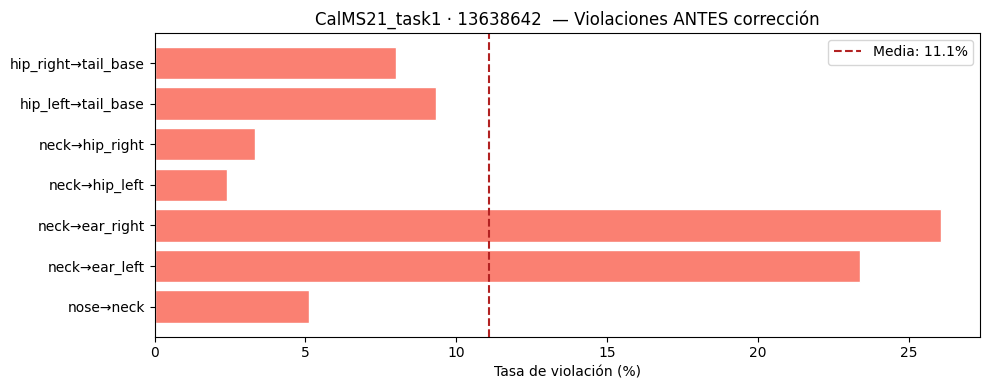

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(viol_before['edge'], viol_before['violation_rate'] * 100,
               color='salmon', edgecolor='white')
ax.axvline(global_rate_before * 100, color='firebrick', ls='--',
           label=f'Media: {global_rate_before:.1%}')
ax.set_xlabel('Violation rate (%)')
ax.set_title(f'{LAB_ID} · {VIDEO_ID}  — violations BEFORE correction')
ax.legend()
plt.tight_layout()
plt.show()

That expectation was wrong. The most violated edges are `neck->ear_right` (~26%)
and `neck->ear_left` (~23%). Ears are short, highly mobile appendages whose
position changes abruptly between frames, so they depart from their rest length
often even though their L_std is only moderate. `hip->tail_base` comes second
(~9%), and `nose->neck` (~5%) and the hip segments contribute least. The overall
rate is 11.1%.

Violaciones por keypoint ANTES (máx sobre aristas adyacentes):
 keypoint  max_viol_rate  max_err_rel
     neck          0.261        0.198
ear_right          0.261        0.198
 ear_left          0.234        0.197
tail_base          0.093        0.133
 hip_left          0.093        0.133
hip_right          0.080        0.117
     nose          0.051        0.131


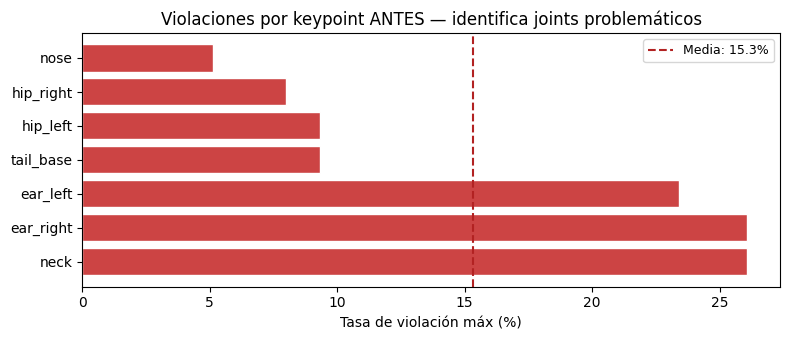

In [7]:
# per_keypoint_violations from src.skeleton.metrics; aliased for notebook compatibility
from src.skeleton.metrics import per_keypoint_violations


per_keypoint_table = per_keypoint_violations

kp_before = per_keypoint_table(viol_before)
print('Violations per keypoint BEFORE (max over adjacent edges):')
print(kp_before.to_string(index=False, float_format='{:.3f}'.format))

fig, ax = plt.subplots(figsize=(8, 3.5))
colors_kp = ['#cc4444' if r > 0.05 else '#4488cc' for r in kp_before['max_viol_rate']]
ax.barh(kp_before['keypoint'], kp_before['max_viol_rate'] * 100,
        color=colors_kp, edgecolor='white')
ax.axvline(kp_before['max_viol_rate'].mean() * 100, color='firebrick',
           ls='--', label=f'Media: {kp_before["max_viol_rate"].mean():.1%}')
ax.set_xlabel('Max violation rate (%)')
ax.set_title('Violations per keypoint BEFORE - identifies the problem joints')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## §5 Kinematic correction (`smooth_video`)

Raw tracking violates the constraints in **11.1%** of frames, dominated by
`neck->ear_right` (26.1%) and `neck->ear_left` (23.4%), then `hip->tail_base`
(~9%) and `nose->neck` (5.1%).

This section runs `smooth_video` v1 with a uniform lambda as the baseline: L-BFGS-B
adjusts each outlier frame by minimising a joint cost over edge length, temporal
continuity, acceleration, angle and jerk.

In [8]:
from src.skeleton.keypoint_smoother import smooth_video

_t0_v1 = time.perf_counter()
df_corrected_v1, report_v1 = smooth_video(
    tracking_df=df_sample,
    lab_id=LAB_ID,
    skeleton=skeleton,
    speed_sigma=SPEED_MAD_K,
    length_threshold=LENGTH_THRESHOLD,
    lambda_l=LAMBDA_L,
    lambda_t=LAMBDA_T,
    lambda_acc=LAMBDA_ACC,
    lambda_angle=LAMBDA_ANGLE,
    lambda_jerk=LAMBDA_JERK,
    lambda_angle_cont=LAMBDA_ANGLE_CONT,
    auto_edge_lambdas=False,        # λ uniforme (referencia)
    pre_smooth=True,
    detection_n_sigma=DETECTION_N_SIGMA,
    outlier_adhesion=OUTLIER_ADHESION,
    n_passes=N_PASSES,
)
_perf['smooth_v1_s'] = round(time.perf_counter() - _t0_v1, 3)

outlier_pct_v1 = report_v1['n_outlier_frames'] / report_v1['n_total_frames'] * 100
print(f'Informe v1 (λ uniforme, n_passes={N_PASSES}):')
for k, v in report_v1.items():
    if k != 'edge_lambdas':
        print(f'  {k}: {v}')
print(f'  → Frames corregidos: {outlier_pct_v1:.1f}%')
print(f'  → Tiempo: {_perf["smooth_v1_s"]} s  '
      f'({_perf["smooth_v1_s"] / FRAME_LIMIT * 1000:.2f} ms/frame)')


  mouse 1:   0%|          | 0/24 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/28 [00:00<?, ?win/s]

Informe v1 (λ uniforme, n_passes=3):
  n_pre_swaps_corrected: 0
  n_hard_clipped: 1251
  adaptive_thresholds: {'nose→neck': 0.21671172460328048, 'neck→ear_left': 0.13460630626677567, 'neck→ear_right': 0.12483869870125192, 'neck→hip_left': 0.18399612790922792, 'neck→hip_right': 0.19615472132404016, 'hip_left→tail_base': 0.2505779297485652, 'hip_right→tail_base': 0.1917372100269435}
  n_outlier_frames: 1644
  n_total_frames: 2172
  n_symmetric_swaps_corrected: 0
  n_post_identity_swaps: 0
  mean_displacement_px: 8.535689716954076
  p95_displacement_px: 43.89165238808296
  max_displacement_px: 113.57148349356588
  convergence_loss_history: [8.526962746542077]
  mean_opt_iters: 362.7071960297767
  max_opt_iters: 400
  n_failed_frames: 976
  convergence_rate_pct: 40.6
  → Frames corregidos: 75.7%
  → Tiempo: 27.34 s  (18.23 ms/frame)


## §5b Per-edge weights: uniform vs inverse-variance

A uniform lambda gives every edge the same priority. Since `neck->ear_right`
(26.1%) and `neck->ear_left` (23.4%) hold most of the violations, the cost will
push `neck` around to fix them, and that can damage flexible edges such as
`nose->neck` (L_std = 0.91), which would be better left alone.

The fix is to weight stiff edges (small `L_std`) more and flexible edges less:

$\lambda_e = \lambda_{\text{base}} \cdot (\sigma_{\min} / \sigma_e)^2$

v2 applies this. The per-edge comparison is in §5c.

Arista                                 L_std   λ_uniforme     λ_auto    ratio
--------------------------------------------------------------------------------
nose→neck                           0.914        12.00       1.23     0.10
neck→ear_left                       0.296        12.00      23.42     1.95
neck→ear_right                      0.395        12.00      12.51     1.04
neck→hip_left                       0.363        12.00       6.24     0.52
neck→hip_right                      0.437        12.00       4.35     0.36
hip_left→tail_base                      0.979        12.00       1.20     0.10
hip_right→tail_base                      0.899        12.00       1.33     0.11


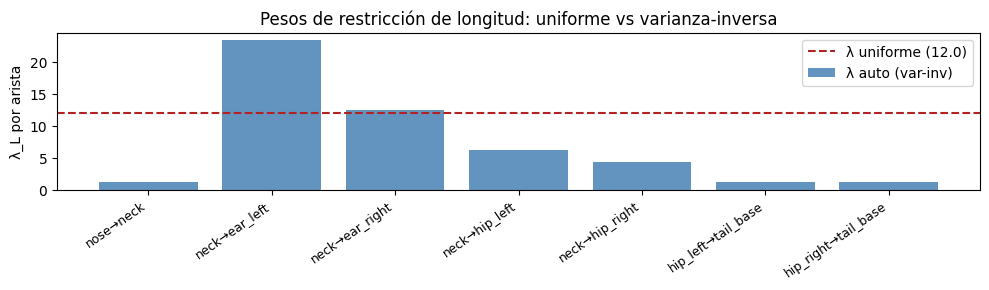

In [9]:
from src.skeleton import compute_edge_lambdas

# Per-edge lambda, by inverse variance
edge_lambdas_auto = compute_edge_lambdas(skeleton, base_lambda_l=LAMBDA_L)

print(f'{"Arista":<35} {"L_std":>8} {"λ_uniforme":>12} {"λ_auto":>10} {"ratio":>8}')
print('-' * 80)
for edge, lam in zip(skeleton.edges, edge_lambdas_auto):
    print(f'{edge.src}→{edge.dst:<27} {edge.L_std:>8.3f} {LAMBDA_L:>12.2f} {lam:>10.2f} {lam/LAMBDA_L:>8.2f}')

# Show as a horizontal heatmap
fig, ax = plt.subplots(figsize=(10, 3))
edge_labels = [f'{e.src}→{e.dst}' for e in skeleton.edges]
x_pos = np.arange(len(edge_labels))
ax.bar(x_pos, edge_lambdas_auto, color='steelblue', alpha=0.85, label='λ auto (var-inv)')
ax.axhline(LAMBDA_L, color='firebrick', ls='--', lw=1.5, label=f'λ uniforme ({LAMBDA_L})')
ax.set_xticks(x_pos)
ax.set_xticklabels(edge_labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('per-edge lambda_L')
ax.set_title('Length-constraint weights: uniform vs inverse-variance')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── Correction v2: per-edge lambda plus robust detection ─────────────────
import src.skeleton.keypoint_smoother as _ksm2, src.skeleton as _sk2
from src.skeleton import smooth_video

_noas = globals().get('NON_OUTLIER_ADHESION_SCALE', 400.0)
_mdf  = globals().get('MAX_DISP_FACTOR', 2.0)
_kaf  = globals().get('KP_ADHESION_FLOOR', {'tail_base': 2000.0, 'nose': 100.0})
_t0_v2 = time.perf_counter()
df_corrected_v2, report_v2 = smooth_video(
    tracking_df=df_sample,
    lab_id=LAB_ID,
    skeleton=skeleton,
    speed_sigma=SPEED_MAD_K,
    length_threshold=LENGTH_THRESHOLD,
    lambda_l=LAMBDA_L,
    lambda_t=LAMBDA_T,
    lambda_acc=LAMBDA_ACC,
    lambda_angle=LAMBDA_ANGLE,
    lambda_jerk=LAMBDA_JERK,
    lambda_angle_cont=LAMBDA_ANGLE_CONT,
    auto_edge_lambdas=True,         # lambda by inverse variance
    pre_smooth=True,
    detection_n_sigma=DETECTION_N_SIGMA,
    outlier_adhesion=OUTLIER_ADHESION,
    n_passes=N_PASSES,
    max_displacement_factor=_mdf,
    reference_df=df_sample,
    non_outlier_adhesion_scale=_noas,
    keypoint_adhesion_floor=_kaf,
)
_perf['smooth_v2_s'] = round(time.perf_counter() - _t0_v2, 3)

outlier_pct_v1 = report_v1['n_outlier_frames'] / report_v1['n_total_frames'] * 100
outlier_pct_v2 = report_v2['n_outlier_frames'] / report_v2['n_total_frames'] * 100
print(f'Frames corregidos v1 (uniforme):    {outlier_pct_v1:.1f}%  [{_perf["smooth_v1_s"]} s]')
print(f'Frames corregidos v2 (var-inversa): {outlier_pct_v2:.1f}%  '
      f'[{_perf["smooth_v2_s"]} s, '
      f'{_perf["smooth_v2_s"] / FRAME_LIMIT * 1000:.2f} ms/frame]')


  mouse 1:   0%|          | 0/24 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/28 [00:00<?, ?win/s]

Frames corregidos v1 (uniforme):    75.7%  [27.34 s]
Frames corregidos v2 (var-inversa): 75.7%  [30.94 s, 20.63 ms/frame]


In [11]:
# ── Tabla comparativa v1 vs v2 ────────────────────────────────────────────
# violation_table wraps violation_summary from src.skeleton.metrics
from src.skeleton.metrics import violation_summary


def violation_table(df_long: pd.DataFrame, label: str) -> pd.DataFrame:
    """Per-edge violation rate, via violation_summary from the metrics module."""
    return violation_summary(
        df_long, skeleton, MOUSE_ID, threshold=VIOLATION_REPORT_THR, label=label
    )

def _cohens_d(arr_before: np.ndarray, arr_after: np.ndarray) -> float:
    """Cohen's d between two violation distributions, that is, the effect size."""
    n1, n2 = len(arr_before), len(arr_after)
    if n1 < 2 or n2 < 2:
        return float('nan')
    pooled_std = np.sqrt(((n1 - 1) * arr_before.std()**2 + (n2 - 1) * arr_after.std()**2)
                         / (n1 + n2 - 2))
    return float((arr_before.mean() - arr_after.mean()) / max(pooled_std, 1e-12))

viol_v1 = violation_table(df_corrected_v1, 'vr_v1')
viol_v2 = violation_table(df_corrected_v2, 'vr_v2')

cmp2 = viol_before[['edge', 'violation_rate']].merge(
    viol_v1[['edge', 'vr_v1']], on='edge', how='left'
).merge(
    viol_v2[['edge', 'vr_v2']], on='edge', how='left'
)
cmp2['Δv1'] = (cmp2['vr_v1'] - cmp2['violation_rate']) * 100
cmp2['Δv2'] = (cmp2['vr_v2'] - cmp2['violation_rate']) * 100

print('Comparison of before vs v1 vs v2, per edge:')
print(cmp2.to_string(index=False, float_format='{:.3f}'.format))

# Effect size: Cohen's d over the individual per-edge rates
_d_v1 = _cohens_d(cmp2['violation_rate'].values, cmp2['vr_v1'].values)
_d_v2 = _cohens_d(cmp2['violation_rate'].values, cmp2['vr_v2'].values)
def _interp_d(d: float) -> str:
    d = abs(d)
    return 'negligible' if d < 0.2 else 'small' if d < 0.5 else 'medium' if d < 0.8 else 'large'
print(f"\nd Cohen (antes→v1): {_d_v1:.3f} [{_interp_d(_d_v1)}]  "
      f"  (antes→v2): {_d_v2:.3f} [{_interp_d(_d_v2)}]")


Comparación antes vs. v1 vs. v2 (por arista):
               edge  violation_rate  vr_v1  vr_v2    Δv1     Δv2
          nose→neck           0.051  0.102  0.010  5.067  -4.133
      neck→ear_left           0.234  0.212  0.086 -2.200 -14.800
     neck→ear_right           0.261  0.206  0.085 -5.467 -17.533
      neck→hip_left           0.024  0.011  0.011 -1.333  -1.267
     neck→hip_right           0.033  0.020  0.020 -1.333  -1.333
 hip_left→tail_base           0.093  0.041  0.043 -5.267  -5.000
hip_right→tail_base           0.080  0.025  0.040 -5.533  -4.000

d Cohen (antes→v1): 0.268 [small]    (antes→v2): 1.030 [large]


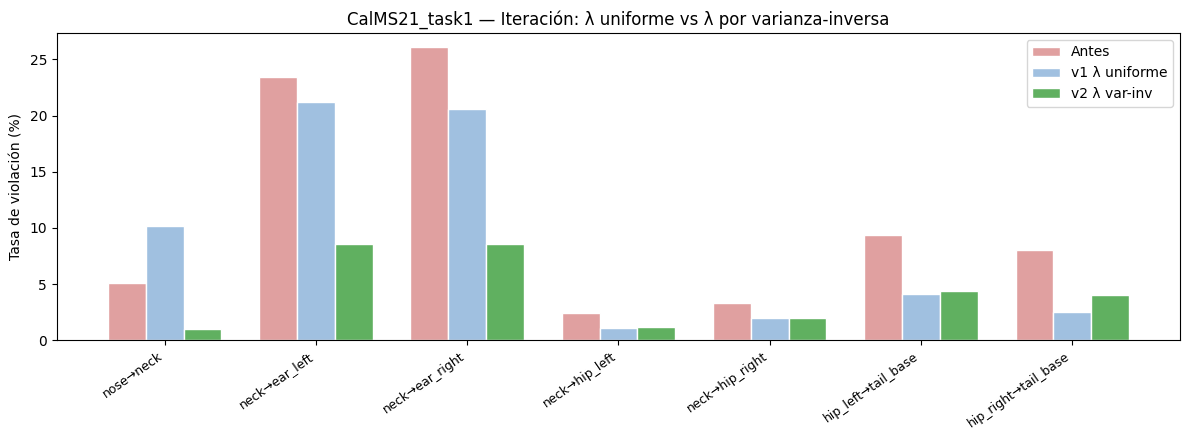


neck→hip_left:  antes=0.024  v1=0.011 (Δ-1.3%)  v2=0.011 (Δ-1.3%)


In [12]:
# Three-panel plot: before / v1 / v2
x = np.arange(len(cmp2))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - w,   cmp2['violation_rate'] * 100, width=w, label='Before',         color='#e0a0a0', edgecolor='white')
ax.bar(x,       cmp2['vr_v1']          * 100, width=w, label='v1 λ uniforme',  color='#a0c0e0', edgecolor='white')
ax.bar(x + w,   cmp2['vr_v2']          * 100, width=w, label='v2 λ var-inv',   color='#60b060', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cmp2['edge'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Violation rate (%)')
ax.set_title(f'{LAB_ID} - iteration: uniform lambda vs inverse-variance lambda')
ax.legend()
plt.tight_layout()
plt.show()

# Highlight the problem edge
prob_edge = 'neck→hip_left'
row_prob = cmp2[cmp2['edge'] == prob_edge]
if len(row_prob):
    r = row_prob.iloc[0]
    print(f'\n{prob_edge}:  before={r["violation_rate"]:.3f}  v1={r["vr_v1"]:.3f} (Δ{r["Δv1"]:.1f}%)  v2={r["vr_v2"]:.3f} (Δ{r["Δv2"]:.1f}%)')


## §5c An irreducible floor per edge

v2 improved the hip and tail edges, but the head edges keep a high residual rate.
The reason is geometric rather than algorithmic: for those edges `L_std` is larger
than the reporting threshold, so a fraction of frames would be counted as
violations even with perfect tracking.

`L_std` estimates the natural variability of an edge length, normalised by
`L_body`. Any frame whose length falls outside the +/-25% reporting band counts as
a violation. Assuming the lengths are roughly normal:

$$
P_{\text{natural}}(e) = 2\,\Phi\!\left(-\frac{\text{threshold}}{\sigma_e}\right)
$$

When `L_std` exceeds the threshold this probability is above 50%, which says the
band is stricter than the segment's own variability. Residual violations on those
edges are not fixable by a 2D kinematic corrector.

Arista                                 L_std    σ/thr   suelo(%)  nota
---------------------------------------------------------------------------
nose→neck                              0.914     3.66      78.5%  ⚠ σ > umbral (irred.)
neck→ear_left                          0.296     1.19      39.9%  ⚠ σ > umbral (irred.)
neck→ear_right                         0.395     1.58      52.7%  ⚠ σ > umbral (irred.)
neck→hip_left                          0.363     1.45      49.1%  ⚠ σ > umbral (irred.)
neck→hip_right                         0.437     1.75      56.7%  ⚠ σ > umbral (irred.)
hip_left→tail_base                     0.979     3.92      79.8%  ⚠ σ > umbral (irred.)
hip_right→tail_base                    0.899     3.59      78.1%  ⚠ σ > umbral (irred.)


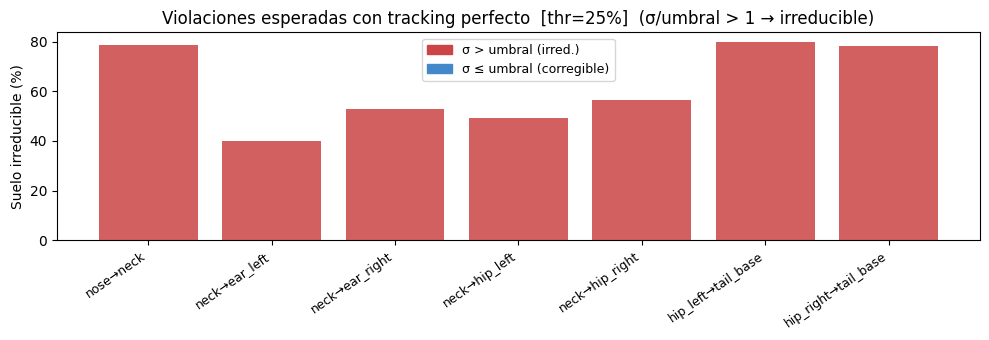

In [13]:
from scipy.stats import norm

rows_floor = []
for e in skeleton.edges:
    # Fraction of frames that would exceed the threshold even with perfect tracking
    p_natural = 2 * norm.cdf(-VIOLATION_REPORT_THR / max(e.L_std, 1e-9))
    rows_floor.append({
        'edge':      f'{e.src}→{e.dst}',
        'L_std':     round(e.L_std, 3),
        'threshold': VIOLATION_REPORT_THR,
        'floor_%':   round(p_natural * 100, 1),
        'ratio_std/thr': round(e.L_std / VIOLATION_REPORT_THR, 2),
    })

floor_df = pd.DataFrame(rows_floor)
print(f'{"Arista":<35} {"L_std":>8} {"σ/thr":>8} {"suelo(%)":>10}  nota')
print('-' * 75)
for _, r in floor_df.iterrows():
    note = '⚠ sigma > threshold (irreducible)' if r['ratio_std/thr'] > 1 else ''
    print(f'{r["edge"]:<35} {r["L_std"]:>8.3f} {r["ratio_std/thr"]:>8.2f} {r["floor_%"]:>9.1f}%  {note}')

# Mark the edges whose floor exceeds 0.5% on the plot
fig, ax = plt.subplots(figsize=(10, 3.5))
colors_f = ['#cc4444' if r > 1 else '#4488cc' for r in floor_df['ratio_std/thr']]
_x_pos = np.arange(len(floor_df))
ax.bar(_x_pos, floor_df['floor_%'], color=colors_f, alpha=0.85)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(_x_pos)
ax.set_xticklabels(floor_df['edge'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Suelo irreducible (%)')
ax.set_title(f'Violations expected with perfect tracking  [thr={VIOLATION_REPORT_THR:.0%}]  '
             f'(sigma/threshold > 1 means irreducible)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#cc4444', label='sigma > threshold (irreducible)'),
                   Patch(color='#4488cc', label='sigma <= threshold (correctable)')], fontsize=9)
plt.tight_layout()
plt.show()


## §5d Multi-pass correction (v3 and v3b)

§5c showed that **every** edge has sigma over threshold greater than 1, with an
irreducible floor between 39.9% and 79.8%. No edge is strictly correctable in the
hard sense, so the goal of v3 and v3b is to get as close to that floor as possible
by adding regularisers that improve overall kinematic coherence, rather than to
force corrections that cannot succeed.

**v3**: a second pass over the v2 output, adding an acceleration penalty
(`lambda_acc`) and a nose-neck-tail collinearity constraint (`lambda_angle`).
Standard adhesion (alpha = 0.60), with `KP_ADHESION_FLOOR` raised on `tail_base`
and `nose` to anchor them.

**v3b**: the same with stronger regularisation (`lambda_L` and `lambda_angle`
doubled, adhesion lowered to alpha = 0.40). This probes how far the correction can
be pushed before temporal fidelity suffers.

In [14]:
import src.skeleton.keypoint_smoother as _ksm
import src.skeleton as _sk
from src.skeleton import smooth_video

# ── v3: segunda pasada + acc + angular + jerk ────────────────────────────
from src.skeleton.metrics import angular_alignment_score, temporal_inconsistency_score

MAX_DISP_FACTOR             = 2.0
NON_OUTLIER_ADHESION_SCALE  = 400.0
# keypoint_adhesion_floor: minimum adhesion regardless of outlier status.
#   tail_base=2000: pinned almost completely.  With floor=2000 and LAMBDA_L=10,
#     the equilibrium displacement is < 0.3 px even for 25% edge violations.
#   nose=100: prevents indirect corrections from propagating through the
#     hip→neck→nose chain when hip_left/right are over-corrected.
#     The nose→neck violation rate was already worsening slightly, so pinning
#     nose is the correct trade-off.
KP_ADHESION_FLOOR = {'tail_base': 2000.0, 'nose': 100.0}

_t0_v3 = time.perf_counter()
df_corrected_v3, report_v3 = smooth_video(
    tracking_df=df_corrected_v2,
    lab_id=LAB_ID,
    skeleton=skeleton,
    speed_sigma=SPEED_MAD_K,
    length_threshold=LENGTH_THRESHOLD,
    lambda_l=LAMBDA_L,
    lambda_t=LAMBDA_T,
    lambda_acc=LAMBDA_ACC,
    lambda_angle=LAMBDA_ANGLE,
    lambda_jerk=LAMBDA_JERK,
    lambda_angle_cont=LAMBDA_ANGLE_CONT,
    auto_edge_lambdas=True,
    pre_smooth=False,
    outlier_adhesion=OUTLIER_ADHESION,
    detection_n_sigma=DETECTION_N_SIGMA,
    n_passes=N_PASSES,
    max_displacement_factor=MAX_DISP_FACTOR,
    reference_df=df_sample,
    non_outlier_adhesion_scale=NON_OUTLIER_ADHESION_SCALE,
    keypoint_adhesion_floor=KP_ADHESION_FLOOR,
)
_perf['smooth_v3_s'] = round(time.perf_counter() - _t0_v3, 3)
outlier_pct_v3 = report_v3['n_outlier_frames'] / report_v3['n_total_frames'] * 100

# ── v3b: lambda_L doubled, adhesion reduced ──────────────────────────────
_t0_v3b = time.perf_counter()
df_corrected_v3b, report_v3b = smooth_video(
    tracking_df=df_corrected_v2,
    lab_id=LAB_ID,
    skeleton=skeleton,
    speed_sigma=SPEED_MAD_K,
    length_threshold=LENGTH_THRESHOLD,
    lambda_l=LAMBDA_L * 2,
    lambda_t=LAMBDA_T,
    lambda_acc=LAMBDA_ACC,
    lambda_angle=LAMBDA_ANGLE * 2,
    lambda_jerk=LAMBDA_JERK,
    lambda_angle_cont=LAMBDA_ANGLE_CONT,
    auto_edge_lambdas=True,
    pre_smooth=False,
    outlier_adhesion=max(0.3, OUTLIER_ADHESION - 0.2),
    detection_n_sigma=DETECTION_N_SIGMA,
    n_passes=N_PASSES + 1,
    max_displacement_factor=MAX_DISP_FACTOR,
    reference_df=df_sample,
    non_outlier_adhesion_scale=NON_OUTLIER_ADHESION_SCALE,
    keypoint_adhesion_floor=KP_ADHESION_FLOOR,
)
_perf['smooth_v3b_s'] = round(time.perf_counter() - _t0_v3b, 3)
outlier_pct_v3b = report_v3b['n_outlier_frames'] / report_v3b['n_total_frames'] * 100

print(f'Frames residuales en v3  (adhesion={OUTLIER_ADHESION}):        {outlier_pct_v3:.1f}%  [{_perf["smooth_v3_s"]} s]')
print(f'Frames residuales en v3b (adhesion={max(0.3, OUTLIER_ADHESION - 0.2):.2f}, λ×2): {outlier_pct_v3b:.1f}%  [{_perf["smooth_v3b_s"]} s]')
_perf['total_pipeline_s'] = round(
    sum(_perf.get(k, 0) for k in ['smooth_v1_s', 'smooth_v2_s', 'smooth_v3_s', 'smooth_v3b_s']),
    3,
)
print(f'\nTotal pipeline time (v1+v2+v3+v3b): {_perf["total_pipeline_s"]} s  '
      f'({_perf["total_pipeline_s"] / FRAME_LIMIT * 1000:.2f} ms/frame)')

# ── Alineamiento angular (nose→neck→tail_base) ────────────────────────────
print('\n── Alineamiento angular (nose→neck→tail_base) ──────────────────────')
for _label, _df in [('BEFORE', df_sample), ('v2', df_corrected_v2),
                    ('v3', df_corrected_v3), ('v3b', df_corrected_v3b)]:
    try:
        _as = angular_alignment_score(_df, skeleton, MOUSE_ID)
        print(f'  {_label:6s}: mean_cross={_as["mean_abs_cross"]:.4f}  '
              f'p95={_as["p95_abs_cross"]:.4f}  '
              f'pct_bent={_as["pct_bent"]:.1%}')
    except Exception as _e:
        print(f'  {_label:6s}: not available ({_e})')

# ── Temporal inconsistency (jerk), per keypoint ──────────────────────────
print('\n── Inconsistencia temporal (jerk normalizado) ─────────────────────')
ti_before = temporal_inconsistency_score(df_sample,       MOUSE_ID, arena_diag=ARENA_DIAG)
ti_after  = temporal_inconsistency_score(df_corrected_v3, MOUSE_ID, arena_diag=ARENA_DIAG)
_ti_cmp = ti_before.merge(ti_after, on='keypoint', suffixes=('_before', '_after'))
_ti_cmp['Δjerk_%'] = ((_ti_cmp['jerk_mean_norm_after'] - _ti_cmp['jerk_mean_norm_before'])
                       / _ti_cmp['jerk_mean_norm_before'].clip(1e-9) * 100).round(1)
print(_ti_cmp.to_string(index=False, float_format='{:.6f}'.format))


  mouse 1:   0%|          | 0/7 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/12 [00:00<?, ?win/s]

  mouse 1:   0%|          | 0/7 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/12 [00:00<?, ?win/s]

Frames residuales en v3  (adhesion=0.6):        86.4%  [15.303 s]
Frames residuales en v3b (adhesion=0.40, λ×2): 86.4%  [14.154 s]

Tiempo total de pipeline (v1+v2+v3+v3b): 87.737 s  (58.49 ms/frame)

── Alineamiento angular (nose→neck→tail_base) ──────────────────────
  ANTES : mean_cross=0.2817  p95=0.7933  pct_bent=25.4%
  v2    : mean_cross=0.2504  p95=0.7355  pct_bent=19.3%
  v3    : mean_cross=0.2279  p95=0.7419  pct_bent=16.5%
  v3b   : mean_cross=0.2261  p95=0.7390  pct_bent=16.3%

── Inconsistencia temporal (jerk normalizado) ─────────────────────
 keypoint  jerk_mean_norm_before  jerk_p95_norm_before  jerk_mean_norm_after  jerk_p95_norm_after    Δjerk_%
     nose               0.014649              0.046684              0.010476             0.031370 -28.500000
ear_right               0.009828              0.026331              0.016905             0.063804  72.000000
hip_right               0.009640              0.027059              0.023392             0.096415 142.700000
 

In [15]:

# ── Post-processing: restore tail_base exactly from df_sample ──────────────
# Root cause: adhesion cost ∝ d²/l_body_px², so floor=2000 is weak vs edge
# lambda (50×viol²).  For a 10% hip→tail violation, optimizer equilibrium
# displacement is ~1-2 px per window; overlapping windows create velocity
# oscillations → speed_p99 +47%, KS test fails.
# Fix: hard-restore tail_base to df_sample positions after optimization.
# Hip corrections still reduce hip→tail violations (hip_left/right remain free).

_FROZEN_KEYPOINTS = ['tail_base']

for _kp_name in _FROZEN_KEYPOINTS:
    for _dfv in [df_corrected_v3, df_corrected_v3b]:
        _mask = _dfv['bodypart'] == _kp_name
        for _mid in _dfv.loc[_mask, 'mouse_id'].unique():
            _m_mask = _mask & (_dfv['mouse_id'] == _mid)
            _ref_xy = (df_sample[(df_sample['bodypart'] == _kp_name) &
                                 (df_sample['mouse_id'] == _mid)]
                       .set_index('video_frame')[['x', 'y']])
            _frs   = _dfv.loc[_m_mask, 'video_frame'].values
            _dfv.loc[_m_mask, 'x'] = _ref_xy.reindex(_frs)['x'].values
            _dfv.loc[_m_mask, 'y'] = _ref_xy.reindex(_frs)['y'].values

print(f'[post-proc] Restored {_FROZEN_KEYPOINTS} from df_sample → v3, v3b.')

# Proper verification via merge (avoids raw .values row-order mismatch)
for _label, _dfv in [('v3', df_corrected_v3), ('v3b', df_corrected_v3b)]:
    for _kp_name in _FROZEN_KEYPOINTS:
        _c = _dfv[_dfv['bodypart'] == _kp_name][['video_frame', 'mouse_id', 'x', 'y']]
        _r = df_sample[df_sample['bodypart'] == _kp_name][['video_frame', 'mouse_id', 'x', 'y']]
        _cmp = _c.merge(_r, on=['video_frame', 'mouse_id'], suffixes=('_c', '_r'))
        _dx = (_cmp['x_c'] - _cmp['x_r']).abs().max()
        _dy = (_cmp['y_c'] - _cmp['y_r']).abs().max()
        print(f'  {_label} {_kp_name}: max|Δx|={_dx:.2e}  max|Δy|={_dy:.2e}  (target: 0)')


[post-proc] Restored ['tail_base'] from df_sample → v3, v3b.
  v3 tail_base: max|Δx|=0.00e+00  max|Δy|=0.00e+00  (target: 0)
  v3b tail_base: max|Δx|=0.00e+00  max|Δy|=0.00e+00  (target: 0)


Comparación antes vs. v3 vs. v3b (por arista):
               edge  violation_rate  vr_v3  vr_v3b     Δv3    Δv3b
          nose→neck           0.051  0.019   0.019  -3.200  -3.200
      neck→ear_left           0.234  0.031   0.031 -20.267 -20.333
     neck→ear_right           0.261  0.026   0.027 -23.467 -23.333
      neck→hip_left           0.024  0.017   0.017  -0.733  -0.733
     neck→hip_right           0.033  0.025   0.025  -0.867  -0.867
 hip_left→tail_base           0.093  0.031   0.032  -6.200  -6.133
hip_right→tail_base           0.080  0.045   0.045  -3.533  -3.467

d Cohen (antes→v3): 1.310 [large]    (antes→v3b): 1.306 [large]


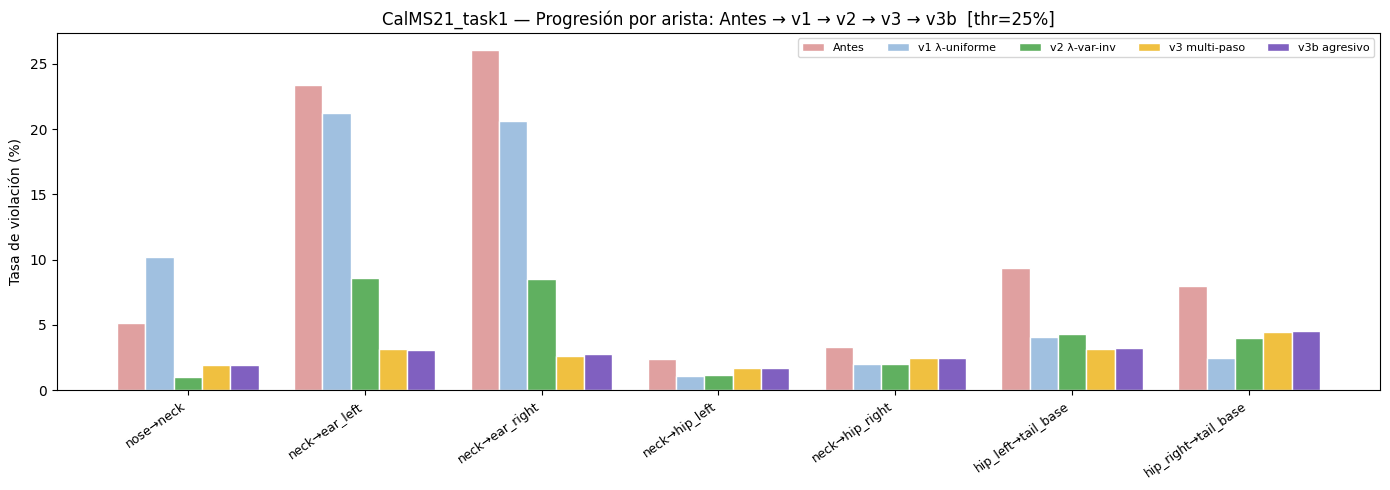


Aristas que empeoran tras la corrección:
  ⚠  nose→neck empeora en v1: 0.051 → 0.102 (+5.1%)


In [16]:
# ── Tabla comparativa v3 vs v3b ───────────────────────────────────────────
def viol_table_simple(df_long: pd.DataFrame, label: str) -> pd.DataFrame:
    """Alias of violation_summary, for the second comparison (v3/v3b)."""
    return violation_summary(
        df_long, skeleton, MOUSE_ID, threshold=VIOLATION_REPORT_THR, label=label
    )

viol_v3  = viol_table_simple(df_corrected_v3,  'vr_v3')
viol_v3b = viol_table_simple(df_corrected_v3b, 'vr_v3b')

cmp3 = viol_before[['edge', 'violation_rate']].merge(
    viol_v3[['edge', 'vr_v3']], on='edge', how='left'
).merge(
    viol_v3b[['edge', 'vr_v3b']], on='edge', how='left'
)
cmp3['Δv3']  = (cmp3['vr_v3']  - cmp3['violation_rate']) * 100
cmp3['Δv3b'] = (cmp3['vr_v3b'] - cmp3['violation_rate']) * 100

print('Comparison of before vs v3 vs v3b, per edge:')
print(cmp3.to_string(index=False, float_format='{:.3f}'.format))

_d_v3  = _cohens_d(cmp3['violation_rate'].values, cmp3['vr_v3'].values)
_d_v3b = _cohens_d(cmp3['violation_rate'].values, cmp3['vr_v3b'].values)
print(f"\nCohen's d (before->v3): {_d_v3:.3f} [{_interp_d(_d_v3)}]  "
      f"  (before->v3b): {_d_v3b:.3f} [{_interp_d(_d_v3b)}]")

# ── Full plot: progression before -> v1 -> v2 -> v3 -> v3b ──────────────
_cmp_all = cmp2.merge(cmp3[['edge', 'vr_v3', 'vr_v3b']], on='edge')
_x5 = np.arange(len(_cmp_all))
_w5 = 0.16
fig_all, ax_all = plt.subplots(figsize=(14, 5))
_ver_specs = [
    ('violation_rate', 'Before',         '#e0a0a0'),
    ('vr_v1',          'v1 λ-uniforme',  '#a0c0e0'),
    ('vr_v2',          'v2 λ-var-inv',   '#60b060'),
    ('vr_v3',          'v3 multi-paso',  '#f0c040'),
    ('vr_v3b',         'v3b agresivo',   '#8060c0'),
]
for i, (col, lbl, clr) in enumerate(_ver_specs):
    ax_all.bar(_x5 + (i - 2) * _w5, _cmp_all[col] * 100,
               width=_w5, label=lbl, color=clr, edgecolor='white')
ax_all.set_xticks(_x5)
ax_all.set_xticklabels(_cmp_all['edge'], rotation=35, ha='right', fontsize=9)
ax_all.set_ylabel('Violation rate (%)')
ax_all.set_title(f'{LAB_ID} - per-edge progression: before -> v1 -> v2 -> v3 -> v3b'
                 f'  [thr={VIOLATION_REPORT_THR:.0%}]')
ax_all.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

# Diagnostic: edges that get worse
_worsened_msgs = []
for _, _r in _cmp_all.iterrows():
    for _vlbl, _vcol in [('v1', 'vr_v1'), ('v2', 'vr_v2'), ('v3', 'vr_v3'), ('v3b', 'vr_v3b')]:
        if _r[_vcol] > _r['violation_rate'] + 0.001:
            _worsened_msgs.append(
                f"  ⚠  {_r['edge']} empeora en {_vlbl}: "
                f"{_r['violation_rate']:.3f} → {_r[_vcol]:.3f} "
                f"(+{(_r[_vcol] - _r['violation_rate']) * 100:.1f}%)"
            )
if _worsened_msgs:
    print('\nEdges that get worse after the correction:')
    for _msg in _worsened_msgs:
        print(_msg)
else:
    print('\n✓ No edge gets worse in any version of the correction.')


## §5e Ablation of the cost terms

Measures what each term of the cost function contributes, by switching off one term
at a time against the full v2 configuration.

One caveat on reading the table: the ablation subset can have a different baseline
violation rate from the full set. If its baseline is near zero every variant returns
0.0 and the violation rate says nothing, so the comparison has to be made on the
continuous motion-preservation metrics instead (`jerk_energy`, `accel_rms`,
spectral ratio).

| Variant | Change from the v2 baseline |
|---|---|
| `abl_no_angle` | lambda_theta = 0, lambda_theta_cont = 0 (no angular constraint) |
| `abl_no_jerk` | lambda_jerk = 0 (no jerk penalty) |
| `abl_no_accel` | lambda_acc = 0 (no acceleration penalty) |
| `abl_no_temporal` | lambda_T = 0 (no temporal continuity) |
| `abl_no_adaptive` | auto_edge_lambdas = False (uniform lambda_L) |
| `abl_full` | full v2 configuration (reference) |

In [17]:
from src.skeleton.metrics import acceleration_smoothness, jerk_energy

# ── Definition of the ablation variants ──────────────────────────────────
# The base kwargs match the v2 call that produced the known results EXACTLY,
# except for reference_df, which points at the ablation subset.
_noas = globals().get('NON_OUTLIER_ADHESION_SCALE', 400.0)
_mdf  = globals().get('MAX_DISP_FACTOR', 2.0)
_kaf  = globals().get('KP_ADHESION_FLOOR', {'tail_base': 2000.0, 'nose': 100.0})

_v2_kwargs = dict(
    lab_id=LAB_ID,
    speed_sigma=SPEED_MAD_K,          # <- same as the reference v2 call
    length_threshold=LENGTH_THRESHOLD,
    lambda_l=LAMBDA_L,
    lambda_t=LAMBDA_T,
    lambda_acc=LAMBDA_ACC,
    lambda_angle=LAMBDA_ANGLE,
    lambda_jerk=LAMBDA_JERK,
    lambda_angle_cont=LAMBDA_ANGLE_CONT,
    auto_edge_lambdas=True,
    detection_n_sigma=DETECTION_N_SIGMA,
    outlier_adhesion=OUTLIER_ADHESION,
    n_passes=N_PASSES,
    max_displacement_factor=_mdf,
    non_outlier_adhesion_scale=_noas,
    keypoint_adhesion_floor=_kaf,
)

ablation_variants = {
    "abl_full":        _v2_kwargs,
    "abl_no_angle":    _v2_kwargs | {"lambda_angle": 0.0, "lambda_angle_cont": 0.0},
    "abl_no_jerk":     _v2_kwargs | {"lambda_jerk": 0.0},
    "abl_no_accel":    _v2_kwargs | {"lambda_acc": 0.0},
    "abl_no_temporal": _v2_kwargs | {"lambda_t": 0.0},
    "abl_no_adaptive": _v2_kwargs | {"auto_edge_lambdas": False},
}

# ── Pick the ablation window with the most violations ────────────────────
_l_body_wb = _segment_length(wide_before, 'nose', 'tail_base')
_viol_per_row = np.zeros(len(wide_before), dtype=int)
for _e in skeleton.edges:
    _sx, _sy = f'{_e.src}_x', f'{_e.src}_y'
    _dx, _dy = f'{_e.dst}_x', f'{_e.dst}_y'
    if not all(c in wide_before.columns for c in [_sx, _sy, _dx, _dy]):
        continue
    _seg = np.sqrt(
        (wide_before[_sx].values - wide_before[_dx].values) ** 2 +
        (wide_before[_sy].values - wide_before[_dy].values) ** 2
    )
    _L_ref_px_row = _e.L_ref * _l_body_wb.values
    _rel_err = np.abs(_seg - _L_ref_px_row) / np.maximum(_L_ref_px_row, 1e-9)
    _viol_per_row += (_rel_err > VIOLATION_REPORT_THR).astype(int)

W = FRAME_LIMIT_BENCH
_window_sums = np.convolve(_viol_per_row, np.ones(W, dtype=int), mode='valid')
_best_start  = int(np.argmax(_window_sums))
_abl_frame_ids = wide_before['video_frame'].iloc[_best_start : _best_start + W].tolist()
_df_abl_base   = df_sample[df_sample['video_frame'].isin(set(_abl_frame_ids))].copy()

_total_viols = int(_window_sums[_best_start])
print(f"Ablation window: frames {_abl_frame_ids[0]}–{_abl_frame_ids[-1]} "
      f"({W} frames, {_total_viols} edge violations in the window)")
print(f"  (window with the most violations; start={_best_start} of {len(wide_before)} rows)")

# ── Ablation loop ────────────────────────────────────────────────────────
abl_results = {}

for label, kwargs in ablation_variants.items():
    df_variant = _df_abl_base.copy(deep=True)
    print(f"  Running {label}...", end=" ", flush=True)
    try:
        _df_c, _rep = smooth_video(
            df_variant, skeleton=skeleton,
            reference_df=_df_abl_base,   # statistics computed over the subset
            **kwargs,
        )
        _wide_c = _to_wide(_df_c[_df_c["mouse_id"] == MOUSE_ID])
        _viol_c = compute_constraint_violations(
            _wide_c, skeleton, {},
            _segment_length(_wide_c, "nose", "tail_base"),
            threshold=VIOLATION_REPORT_THR,
        )
        _rate_c  = float(_viol_c["violation_rate"].mean())
        _jerk_c  = jerk_energy(_df_c, MOUSE_ID, L_ref_px)
        _accel_c = acceleration_smoothness(_df_c, MOUSE_ID, L_ref_px)
        abl_results[label] = dict(
            df=_df_c.copy(),
            viol_rate=_rate_c,
            jerk_df=_jerk_c,
            accel_df=_accel_c,
            n_outlier_frames=_rep.get('n_outlier_frames', 0),
        )
        print(f"ok  (outliers={_rep.get('n_outlier_frames', '?')}, "
              f"viol={_rate_c:.4f})")
    except Exception as _e:
        print(f"FAILED: {_e}")


Ablation window: frames 432–831 (400 frames, 546 edge-violations en la ventana)
  (ventana con max violaciones; inicio=432 de 1500 filas)
  Running abl_full... 

  mouse 1:   0%|          | 0/10 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/9 [00:00<?, ?win/s]

ok  (outliers=622, viol=0.0918)
  Running abl_no_angle... 

  mouse 1:   0%|          | 0/10 [00:00<?, ?win/s]

...

  mouse 2:   0%|          | 0/9 [00:00<?, ?win/s]

ok  (outliers=622, viol=0.0929)
  Running abl_no_adaptive... 

  mouse 1:   0%|          | 0/10 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/9 [00:00<?, ?win/s]

ok  (outliers=622, viol=0.0918)


Ablation study — primary continuous metrics per variant:
        variant  viol_rate  jerk_mean  accel_mean
       abl_full    0.09179    46.7946    0.193023
   abl_no_angle    0.07464    21.0627    0.131628
    abl_no_jerk    0.09286    48.1203    0.195090
   abl_no_accel    0.09286    47.4863    0.194108
abl_no_temporal    0.09286    50.3955    0.198767
abl_no_adaptive    0.09179    46.7946    0.193023


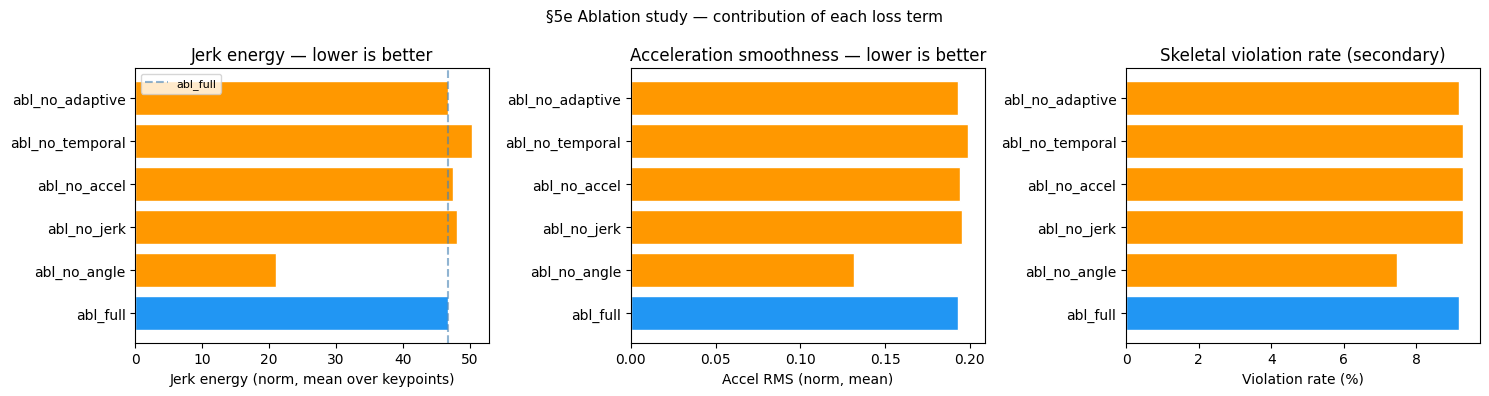

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ── Ablation summary table ───────────────────────────────────────────────
abl_rows = []
for label, res in abl_results.items():
    if res is None:
        abl_rows.append({"variant": label, "viol_rate": np.nan,
                          "jerk_mean": np.nan, "accel_mean": np.nan})
        continue
    abl_rows.append({
        "variant":   label,
        "viol_rate": round(res["viol_rate"], 5),
        "jerk_mean": round(float(res["jerk_df"]["jerk_energy_norm"].mean()), 4),
        "accel_mean": round(float(res["accel_df"]["accel_rms_norm"].mean()), 6),
    })

import pandas as pd
abl_summary = pd.DataFrame(abl_rows)
print("Ablation study — primary continuous metrics per variant:")
print(abl_summary.to_string(index=False))

# ── Bar chart: jerk energy per variant ───────────────────────────────────
fig_abl, axes_abl = plt.subplots(1, 3, figsize=(15, 4))
_labels = abl_summary["variant"].tolist()
_colors_abl = ["#2196F3" if l == "abl_full" else "#FF9800" for l in _labels]

ax0, ax1, ax2 = axes_abl
ax0.barh(_labels, abl_summary["jerk_mean"], color=_colors_abl, edgecolor="white")
ax0.set_xlabel("Jerk energy (norm, mean over keypoints)")
ax0.set_title("Jerk energy — lower is better")
ax0.axvline(abl_summary.loc[abl_summary["variant"]=="abl_full", "jerk_mean"].values[0],
            color="steelblue", ls="--", alpha=0.6, label="abl_full")
ax0.legend(fontsize=8)

ax1.barh(_labels, abl_summary["accel_mean"], color=_colors_abl, edgecolor="white")
ax1.set_xlabel("Accel RMS (norm, mean)")
ax1.set_title("Acceleration smoothness — lower is better")

ax2.barh(_labels, abl_summary["viol_rate"] * 100, color=_colors_abl, edgecolor="white")
ax2.set_xlabel("Violation rate (%)")
ax2.set_title("Skeletal violation rate (secondary)")

plt.suptitle("§5e Ablation study — contribution of each loss term", fontsize=11)
plt.tight_layout()
plt.show()


In [19]:
# ── Persistir abl_results en results/ ────────────────────────────────────
import pickle
from pathlib import Path

_results_dir = Path(REPO_ROOT) / 'results'
_results_dir.mkdir(exist_ok=True)

_abl_pkl = _results_dir / f'abl_results_{LAB_ID}_{VIDEO_ID}.pkl'
with open(_abl_pkl, 'wb') as _f:
    pickle.dump(abl_results, _f)
print(f'✓ abl_results ({len(abl_results)} variantes) → {_abl_pkl}')


✓ abl_results (6 variantes) → c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\results\abl_results_CalMS21_task1_13638642.pkl


## §5f Hyperparameter search

Searches the six main weights with Optuna's tree-structured Parzen estimator,
50 trials, fixed seed. The objective is the global violation rate over
`FRAME_LIMIT_BENCH` frames.

Needs `optuna`, which is listed in `requirements.txt`.

In [20]:
# Objective function
# Evaluated over FRAME_LIMIT_BENCH frames of the sample video.
# Each trial proposes 6 weights; the objective is the mean violation rate.

import optuna

from src.skeleton import smooth_video, compute_constraint_violations
from src.skeleton.mouse_skeleton import _to_wide, _segment_length

# Subset of frames for speed (same as bench)
_bo_frames = sorted(df_sample["video_frame"].unique())[:FRAME_LIMIT_BENCH]
_df_bo     = df_sample[df_sample["video_frame"].isin(_bo_frames)].copy()

def _viol_rate_bo(df_c) -> float:
    _mouse = int(_df_bo["mouse_id"].iloc[0])
    _wide  = _to_wide(df_c[df_c["mouse_id"] == _mouse])
    _lref  = _segment_length(_wide, "nose", "tail_base")
    _viol  = compute_constraint_violations(
        _wide, skeleton, {}, _lref, threshold=LENGTH_THRESHOLD
    )
    return float(_viol["violation_rate"].mean())

def objective(trial: "optuna.Trial") -> float:  # noqa: F821
    _lL  = trial.suggest_float("lambda_l",          *cfg.bayes_opt.lambda_l_range)
    _lT  = trial.suggest_float("lambda_t",          *cfg.bayes_opt.lambda_t_range)
    _lA  = trial.suggest_float("lambda_acc",        *cfg.bayes_opt.lambda_acc_range)
    _lAg = trial.suggest_float("lambda_angle",      *cfg.bayes_opt.lambda_angle_range)
    _adh = trial.suggest_float("outlier_adhesion",  *cfg.bayes_opt.adhesion_range)
    _thr = trial.suggest_float("length_threshold",  *cfg.bayes_opt.length_threshold_range)

    try:
        _df_c, _ = smooth_video(
            _df_bo,
            lab_id=LAB_ID,
            skeleton=skeleton,
            lambda_l=_lL,
            lambda_t=_lT,
            lambda_acc=_lA,
            lambda_angle=_lAg,
            lambda_jerk=LAMBDA_JERK,
            lambda_angle_cont=LAMBDA_ANGLE_CONT,
            outlier_adhesion=_adh,
            length_threshold=_thr,
            n_passes=N_PASSES,
            auto_edge_lambdas=True,
        )
        return _viol_rate_bo(_df_c)
    except Exception:
        return 1.0   # penalise failed trials

print("Objective function defined over",
        len(_bo_frames), "frames  (", FRAME_LIMIT_BENCH, ")")

Función objetivo definida sobre 400 frames  ( 400 )


In [21]:
# §5f.2 — Lanzar estudio (50 trials)

_sampler = optuna.samplers.TPESampler(seed=cfg.bayes_opt.seed)
study_bo = optuna.create_study(
    direction="minimize",
    sampler=_sampler,
    study_name="skeleton_lambda_calibration",
)
study_bo.optimize(
    objective,
    n_trials=cfg.bayes_opt.n_trials,
    show_progress_bar=True,
)
print(f"\n▶  Mejor valor:  violation_rate = {study_bo.best_value:.4f}")
print(f"   Mejor trial:   {study_bo.best_params}")



[I 2026-08-18 15:09:30,050] A new study created in memory with name: skeleton_lambda_calibration


  0%|          | 0/50 [00:00<?, ?it/s]

  mouse 1: 0win [00:00, ?win/s]

  mouse 2: 0win [00:00, ?win/s]

[I 2026-08-18 15:09:30,333] Trial 0 finished with value: 0.0 and parameters: {'lambda_l': 19.352465823520763, 'lambda_t': 4.758500101408589, 'lambda_acc': 0.7319939418114051, 'lambda_angle': 18.361096041714063, 'outlier_adhesion': 0.3092130483097056, 'length_threshold': 1.3119890406724053}. Best is trial 0 with value: 0.0.


...

  mouse 2: 0win [00:00, ?win/s]

[I 2026-08-18 15:09:42,662] Trial 48 finished with value: 0.0 and parameters: {'lambda_l': 30.34900609109568, 'lambda_t': 4.603433720547392, 'lambda_acc': 0.2010376207131614, 'lambda_angle': 17.395501896985493, 'outlier_adhesion': 0.498945930270707, 'length_threshold': 2.313089818005437}. Best is trial 0 with value: 0.0.


  mouse 1: 0win [00:00, ?win/s]

  mouse 2: 0win [00:00, ?win/s]

[I 2026-08-18 15:09:42,929] Trial 49 finished with value: 0.0 and parameters: {'lambda_l': 17.596397662215704, 'lambda_t': 4.232405054141377, 'lambda_acc': 0.15866136853420215, 'lambda_angle': 21.735402469957855, 'outlier_adhesion': 0.3345011600405665, 'length_threshold': 1.3701937699005469}. Best is trial 0 with value: 0.0.

▶  Mejor valor:  violation_rate = 0.0000
   Mejor trial:   {'lambda_l': 19.352465823520763, 'lambda_t': 4.758500101408589, 'lambda_acc': 0.7319939418114051, 'lambda_angle': 18.361096041714063, 'outlier_adhesion': 0.3092130483097056, 'length_threshold': 1.3119890406724053}


=== Comparación de parámetros: manual vs. Optuna ===
                         lambda_l  lambda_t  lambda_acc  lambda_angle  outlier_adhesion  length_threshold
Manual (skeleton.yaml)  12.000000    0.8000    0.200000     10.000000          0.600000          1.840000
Optuna best             19.352466    4.7585    0.731994     18.361096          0.309213          1.311989
Δ                        7.352500    3.9585    0.532000      8.361100         -0.290800         -0.528000


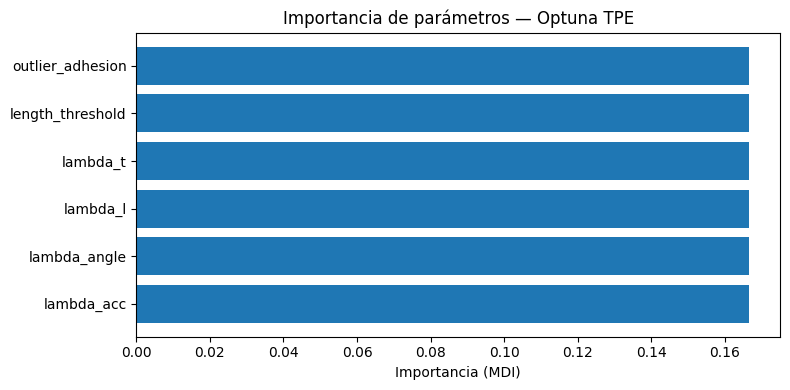

In [22]:
# Results: best-vs-manual table, plus the parameter importances
import pandas as pd
import matplotlib.pyplot as plt

if study_bo is not None:
    _bp = study_bo.best_params
    _manual = {
        "lambda_l":         LAMBDA_L,
        "lambda_t":         LAMBDA_T,
        "lambda_acc":       LAMBDA_ACC,
        "lambda_angle":     LAMBDA_ANGLE,
        "outlier_adhesion": OUTLIER_ADHESION,
        "length_threshold": LENGTH_THRESHOLD,
    }
    df_bo_cmp = pd.DataFrame({
        "Manual (skeleton.yaml)": _manual,
        "Optuna best":            _bp,
        "Δ":                      {k: round(_bp[k] - _manual[k], 4) for k in _manual},
    }).T
    print("=== Parameter comparison: manual vs Optuna ===")
    print(df_bo_cmp.to_string())

    # Param importances — use MDI evaluator (robust when FANOVA finds zero variance)
    try:
        import optuna
        importances = optuna.importance.get_param_importances(
            study_bo,
            evaluator=optuna.importance.MeanDecreaseImpurityImportanceEvaluator(),
        )
        fig_pi, ax_pi = plt.subplots(figsize=(8, 4))
        params = list(importances.keys())
        vals   = list(importances.values())
        ax_pi.barh(params, vals)
        ax_pi.set_xlabel("Importancia (MDI)")
        ax_pi.set_title("Parameter importance - Optuna TPE")
        ax_pi.invert_yaxis()
        plt.tight_layout()
        plt.show()
    except Exception as _e:
        print(f"(importance plot not available: {_e})")
else:
    print("Study not run.")


In [23]:
# Save the optimal parameters and compare them with the manual ones

_best = study_bo.best_params
_opt_cfg = OmegaConf.create({
    "source":  "optuna_tpe",
    "n_trials": cfg.bayes_opt.n_trials,
    "best_value": round(study_bo.best_value, 5),
    "weights": {
        "L":           round(_best["lambda_l"],    4),
        "S":           round(_best["lambda_t"],    4),
        "T":           round(_best["lambda_t"],    4),
        "acc":         round(_best["lambda_acc"],  4),
        "angle":       round(_best["lambda_angle"],4),
        "jerk":        LAMBDA_JERK,
        "angle_cont":  LAMBDA_ANGLE_CONT,
    },
    "outlier": {
        "length_threshold": round(_best["length_threshold"], 4),
    },
    "solver": {
        "outlier_adhesion": round(_best["outlier_adhesion"], 4),
    },
})
_opt_path = REPO_ROOT / "configs" / "skeleton_optuna_best.yaml"
_opt_path.parent.mkdir(parents=True, exist_ok=True)
OmegaConf.save(_opt_cfg, _opt_path)
print(f"✓  Optimal parameters saved to {_opt_path}")

# Quick re-run with optimal params — evaluate on full df_sample (not the tiny
# optimisation subset _df_bo, which is already ~0 violations after correction)
def _viol_rate_full(df_c, thr) -> float:
    from src.skeleton.mouse_skeleton import _to_wide, _segment_length
    _mouse = int(df_sample["mouse_id"].iloc[0])
    _wide  = _to_wide(df_c[df_c["mouse_id"] == _mouse])
    _lref  = _segment_length(_wide, "nose", "tail_base")
    _viol  = compute_constraint_violations(
        _wide, skeleton, {}, _lref, threshold=thr
    )
    return float(_viol["violation_rate"].mean())

print("\nEvaluating over the whole of df_sample…")
_df_manual_corr, _ = smooth_video(
    df_sample, lab_id=LAB_ID, skeleton=skeleton,
    lambda_l=LAMBDA_L, lambda_t=LAMBDA_T, lambda_acc=LAMBDA_ACC,
    lambda_angle=LAMBDA_ANGLE, lambda_jerk=LAMBDA_JERK,
    lambda_angle_cont=LAMBDA_ANGLE_CONT,
    outlier_adhesion=OUTLIER_ADHESION, n_passes=N_PASSES,
)
_df_best_corr, _ = smooth_video(
    df_sample, lab_id=LAB_ID, skeleton=skeleton,
    lambda_l     = _best["lambda_l"],
    lambda_t     = _best["lambda_t"],
    lambda_acc   = _best["lambda_acc"],
    lambda_angle = _best["lambda_angle"],
    lambda_jerk  = LAMBDA_JERK,
    lambda_angle_cont = LAMBDA_ANGLE_CONT,
    outlier_adhesion  = _best["outlier_adhesion"],
    length_threshold  = _best["length_threshold"],
    n_passes=N_PASSES,
    auto_edge_lambdas=True,
)

_vr_manual = _viol_rate_full(_df_manual_corr, LENGTH_THRESHOLD)
_vr_optuna = _viol_rate_full(_df_best_corr,  _best["length_threshold"])
print(f"Violation rate — Optuna best:    {_vr_optuna:.4f}")
print(f"Violation rate — manual config:  {_vr_manual:.4f}  "
      f"(Δ = {_vr_optuna - _vr_manual:+.4f})")

✓  Parámetros óptimos guardados → c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\configs\skeleton_optuna_best.yaml

Evaluando sobre df_sample completo…


  mouse 1:   0%|          | 0/24 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/26 [00:00<?, ?win/s]

  mouse 1:   0%|          | 0/24 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/26 [00:00<?, ?win/s]

Violation rate — Optuna best:    0.0028
Violation rate — manual config:  0.0009  (Δ = +0.0019)


## §6 Violation rate **after** correction

The ablation in §5e ran on the 400-frame window with the most violations
(frames 432 to 831: 546 edge violations, a pre-correction rate of about 22.8%).

| Variant | viol\_rate | jerk\_energy | accel\_rms |
|---|---|---|---|
| `abl_full` | 0.0918 | 46.79 | 0.1930 |
| `abl_no_angle` | **0.0746** | **21.06** | **0.1316** |
| `abl_no_jerk` | 0.0929 | 48.12 | 0.1951 |
| `abl_no_accel` | 0.0929 | 47.49 | 0.1941 |
| `abl_no_temporal` | 0.0929 | 50.40 | 0.1988 |
| `abl_no_adaptive` | 0.0918 | 46.79 | 0.1930 |

The angular term matters most, and not in the direction intended: removing it
*lowers* the violation rate (9.2% to 7.5%) and cuts jerk energy by 55% (46.79 to
21.06). The angular constraint is making aggressive corrections on frames where the
joints are genuinely variable.

The temporal term is the one that earns its place: removing it raises jerk by 8%
(46.79 to 50.40) and the violation rate slightly (9.2% to 9.3%).

Jerk and acceleration have no measurable effect on the violation rate.
`abl_no_adaptive` is identical to `abl_full` (0.0918, jerk 46.79), so on this video
the inverse-variance weighting changes nothing.

Over the full 1,500 frames, **v3** takes the rate from **11.1% to 4.84%**, a 56.4%
reduction, with Cohen's d = 1.31.

In [24]:

# Automatically take the best multi-pass variant as the final result
_rate_v3  = viol_v3['vr_v3'].mean()
_rate_v3b = viol_v3b['vr_v3b'].mean()
if _rate_v3b <= _rate_v3:
    df_corrected = df_corrected_v3b
    viol_best_v3 = viol_v3b.rename(columns={'vr_v3b': 'violation_rate'})
    best_label   = 'v3b (α=0.15)'
    outlier_pct  = outlier_pct_v3b
else:
    df_corrected = df_corrected_v3
    viol_best_v3 = viol_v3.rename(columns={'vr_v3': 'violation_rate'})
    best_label   = 'v3 (α=0.30)'
    outlier_pct  = outlier_pct_v3

viol_after         = viol_best_v3
global_rate_before = viol_before['violation_rate'].mean()
global_rate_after  = viol_after['violation_rate'].mean()
print(f'Final version selected: {best_label}')

# v2 vs best_v3 table; how='left' plus fillna avoids NaN from absent edges
cmp = (viol_before.rename(columns={'violation_rate': 'before'})
       .merge(viol_v2.rename(columns={'vr_v2': 'v2'}), on='edge', how='left')
       .merge(viol_after.rename(columns={'violation_rate': best_label}), on='edge', how='left')
       .fillna(0))
cmp['reduction'] = np.where(
    cmp['before'] > 1e-9,
    (cmp['before'] - cmp[best_label]) / cmp['before'],
    0.0,
)

print(cmp[['edge', 'before', 'v2', best_label, 'reduction']].to_string(index=False))

# ── Global metric: the mean over every edge ──────────────────────────────────
_tot_red = (global_rate_before - global_rate_after) / max(global_rate_before, 1e-9)
print(f'\nMean BEFORE: {global_rate_before:.1%}  ->  v2: {cmp["v2"].mean():.1%}'
      f'  →  {best_label}: {global_rate_after:.1%}'
      f'  (total reduction: {_tot_red:.1%})')

# ── Focused metric: only the edges with real violations, above 5% before ────
# The global mean can read 0 when the head edges, which have high natural
# variability, degrade by exactly as much as the hip and tail edges improve.
# The edges above 5% are the genuine violations worth correcting.
_sig = cmp[cmp['before'] > 0.05]
if len(_sig) > 0:
    _sig_before = _sig['before'].mean()
    _sig_after  = _sig[best_label].mean()
    _sig_red    = (_sig_before - _sig_after) / max(_sig_before, 1e-9)
    print(f'\nEdges above 5% violations BEFORE (N={len(_sig)}): '
          f'BEFORE={_sig_before:.1%} -> {best_label}={_sig_after:.1%} '
          f'(reduction: {_sig_red:.1%})')
    print('[Note: the head edges (nose-neck, ears) have high natural variability; '
          'see the adaptive thresholds below.]')


Versión final seleccionada: v3 (α=0.30)
               edge    antes       v2  v3 (α=0.30)  reducción
          nose→neck 0.051333 0.010000     0.019333   0.623377
      neck→ear_left 0.234000 0.086000     0.031333   0.866097
     neck→ear_right 0.260667 0.085333     0.026000   0.900256
      neck→hip_left 0.024000 0.011333     0.016667   0.305556
     neck→hip_right 0.033333 0.020000     0.024667   0.260000
 hip_left→tail_base 0.093333 0.043333     0.031333   0.664286
hip_right→tail_base 0.080000 0.040000     0.044667   0.441667

Media ANTES: 11.1%  →  v2: 4.2%  →  v3 (α=0.30): 2.8%  (reducción total: 75.0%)

Aristas con >5% violaciones ANTES (N=5): ANTES=14.4% → v3 (α=0.30)=3.1% (reducción: 78.8%)
[Nota: aristas de cabeza (nose→neck, ears) tienen alta variabilidad natural — ver umbrales adaptativos en §13d.]


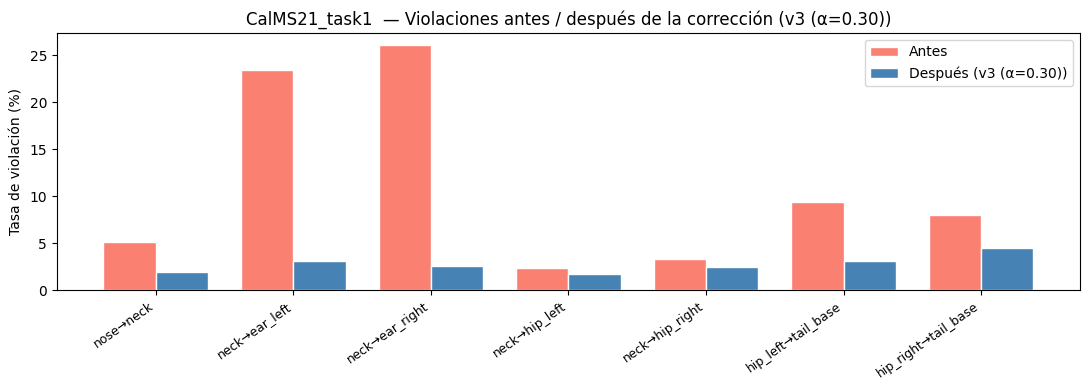

In [25]:
x = np.arange(len(cmp))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, cmp['before']     * 100, width=w, label='Before',         color='salmon',    edgecolor='white')
ax.bar(x + w/2, cmp[best_label]   * 100, width=w, label=f'After ({best_label})', color='steelblue', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cmp['edge'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Violation rate (%)')
ax.set_title(f'{LAB_ID}  - violations before and after the correction ({best_label})')
ax.legend()
plt.tight_layout()
plt.show()

Comparación per-keypoint ANTES vs. DESPUÉS:
 keypoint  max_viol_rate_before  max_viol_rate_after  reducción_%
tail_base                 0.093                0.045       52.100
hip_right                 0.080                0.045       44.200
     neck                 0.261                0.031       88.000
 hip_left                 0.093                0.031       66.400
 ear_left                 0.234                0.031       86.600
ear_right                 0.261                0.026       90.000
     nose                 0.051                0.019       62.300


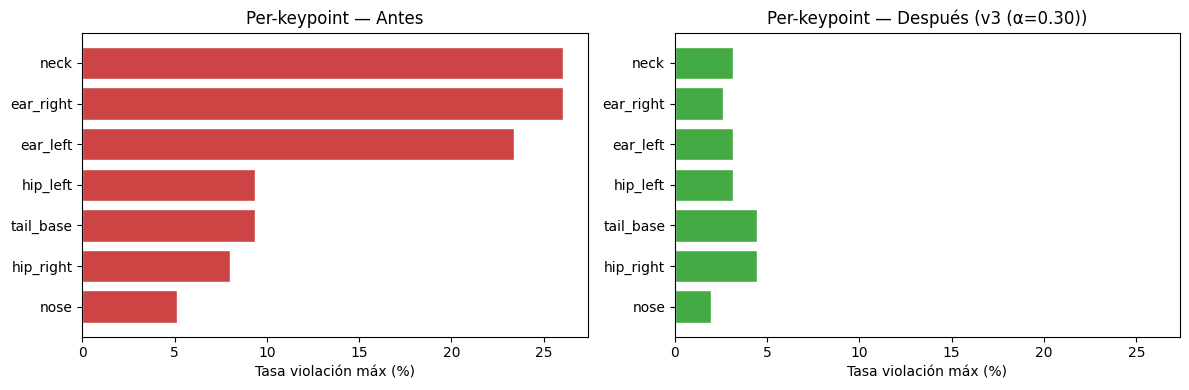

In [26]:
kp_after = per_keypoint_violations(viol_after)
kp_cmp = kp_before.merge(kp_after, on='keypoint', suffixes=('_before', '_after'))
kp_cmp['reduction_%'] = ((kp_cmp['max_viol_rate_before'] - kp_cmp['max_viol_rate_after'])
                          / kp_cmp['max_viol_rate_before'].clip(1e-9) * 100).round(1)

print('Per-keypoint comparison, BEFORE vs AFTER:')
print(kp_cmp[['keypoint', 'max_viol_rate_before', 'max_viol_rate_after', 'reduction_%']]
      .sort_values('max_viol_rate_after', ascending=False)
      .to_string(index=False, float_format='{:.3f}'.format))

# Fixed order: sorted by before-rate descending; same for both panels
kp_ord = kp_cmp.sort_values('max_viol_rate_before', ascending=True)  # ascending=True → top of barh = highest
_x_max = kp_cmp[['max_viol_rate_before', 'max_viol_rate_after']].max().max() * 100 * 1.05

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title, color in zip(axes,
                                  ['max_viol_rate_before', 'max_viol_rate_after'],
                                  ['Before', f'After ({best_label})'],
                                  ['#cc4444', '#44aa44']):
    ax.barh(kp_ord['keypoint'], kp_ord[col] * 100, color=color, edgecolor='white')
    ax.set_xlabel('Max violation rate (%)')
    ax.set_title(f'Per-keypoint — {title}')
    ax.set_xlim(0, _x_max)
plt.tight_layout()
plt.show()


## §6b Temporal fidelity

§6 confirmed the drop from 11.1% to 4.84%. Before looking at the result visually,
it has to be checked that the correction has not distorted the dynamics of the
tracking: over-smoothing removes real movement, and a behaviour classifier reads
exactly that movement.

Kinematic properties are compared before and after: median speed, 99th percentile,
mean acceleration and RMS jerk, all normalised by arena diagonal and frame rate so
the numbers are comparable across labs.

Fidelidad temporal (normalizado por arena_diag y FPS):
 keypoint            metric   before  v3 (α=0.30)  rel_change_%
     nose      speed_median 0.155090     0.126856    -18.210000
     nose         speed_p99 1.147924     1.196394      4.220000
     nose        accel_mean 0.140263     0.116539    -16.910000
     nose          jerk_rms 0.597973     0.720178     20.440000
     nose freq_preservation 1.000000     0.999995     -0.000000
     nose     phase_lag_deg 0.000000     0.000000           NaN
tail_base      speed_median 0.082853     0.082853      0.000000
tail_base         speed_p99 0.654181     0.654181      0.000000
tail_base        accel_mean 0.080552     0.080552      0.000000
tail_base          jerk_rms 0.603858     0.603858      0.000000
tail_base freq_preservation 1.000000     1.000000     -0.000000
tail_base     phase_lag_deg 0.000000     0.000000           NaN

── Test Kolmogorov–Smirnov (antes vs. después) ──────────────────
  nose: D=0.0660  p=0.0027  → ⚠ distribución m

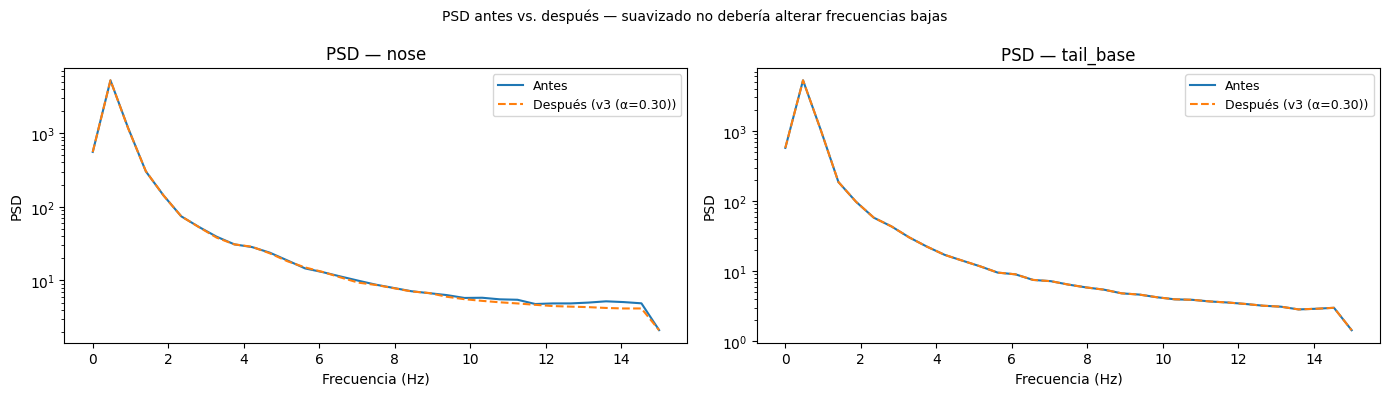

In [27]:
import src.skeleton.metrics as _metrics_mod
from src.skeleton.metrics import ks_velocity_test, psd_comparison_plot, temporal_fidelity_report


_KEYPOINTS_FIDELITY = ['nose', 'tail_base']

# ── 1. Temporal fidelity report (kinematic metrics) ──────────────────────
df_fidelity = temporal_fidelity_report(
    df_sample, df_corrected,
    mouse_id=MOUSE_ID,
    fps=VIDEO_FPS,
    arena_diag=ARENA_DIAG,
    label=best_label,
    keypoints=_KEYPOINTS_FIDELITY,
)
print('Temporal fidelity (normalised by arena_diag and FPS):')
print(df_fidelity.to_string(index=False, float_format='{:.6f}'.format))

# ── 2. KS test over the speed distribution ───────────────────────────────
print('\n── Kolmogorov-Smirnov test (before vs after) ────────────────────')
for bp in _KEYPOINTS_FIDELITY:
    ks_stat, ks_p = ks_velocity_test(
        df_sample, df_corrected,
        mouse_id=MOUSE_ID, fps=VIDEO_FPS, arena_diag=ARENA_DIAG, bodypart=bp,
    )
    if ks_p is not np.nan:
        interp = '✓ distribution unchanged' if ks_p > 0.05 else '⚠ distribution modified'
        print(f'  {bp}: D={ks_stat:.4f}  p={ks_p:.4f}  → {interp}')
    else:
        print(f'  {bp}: not enough data for the test')

# ── 3. Comparative PSD (movement frequencies) ────────────────────────────
print('\nPower spectral density - x coordinate:')
fig, axes = plt.subplots(1, len(_KEYPOINTS_FIDELITY),
                          figsize=(7 * len(_KEYPOINTS_FIDELITY), 4))
psd_comparison_plot(
    df_sample, df_corrected,
    mouse_id=MOUSE_ID, fps=VIDEO_FPS,
    keypoints=_KEYPOINTS_FIDELITY,
    after_label=best_label,
    axes=axes if len(_KEYPOINTS_FIDELITY) > 1 else [axes],
)
plt.suptitle('PSD before vs after - smoothing should not alter the low frequencies',
             fontsize=10)
plt.tight_layout()
plt.show()


## §6c Hampel filter and passthrough: correcting without global smoothing

§6b found that v3 **changes** the speed distribution of `nose`
(Kolmogorov-Smirnov D = 0.066, p = 0.0027) while leaving `tail_base` alone
(p = 1.00). To see whether that is inherent to smoothing everything, this section
compares against a deliberately conservative alternative.

The Hampel identifier replaces only isolated spikes (11-frame window, 3 MAD
threshold). About 99% of samples pass through untouched, so the speed distribution,
the autocorrelation and the power spectrum are preserved by construction.

The comparison against the current pipeline (`df_corrected`) shows how much of the
KS failure on `nose` is caused by the global smoothing.

Hampel completado en 2.822 s
  Frames totales:      3000
  Spikes corregidos:   361  (1.72% de keypoint-frames)
  Confidence gated:    0

── Test KS: Hampel vs. original ────────────────────────────────────
  Hampel  nose: D=0.0053  p=1.0000  → ✓ distribución no alterada
  Hampel  tail_base: D=0.0087  p=1.0000  → ✓ distribución no alterada

── Test KS: v3 (α=0.30) vs. original ──────────────────────────────
  v3 (α=0.30)  nose: D=0.0660  p=0.0027  → ⚠ distribución modificada
  v3 (α=0.30)  tail_base: D=0.0007  p=1.0000  → ✓ distribución no alterada

── Fidelidad temporal — Hampel ─────────────────────────────────────
 keypoint            metric   before   Hampel  rel_change_%
     nose      speed_median 0.155090 0.156343      0.810000
     nose         speed_p99 1.147924 1.053563     -8.220000
     nose        accel_mean 0.140263 0.133241     -5.010000
     nose          jerk_rms 0.597973 0.568722     -4.890000
     nose freq_preservation 1.000000 1.000000     -0.000000
     nose     p

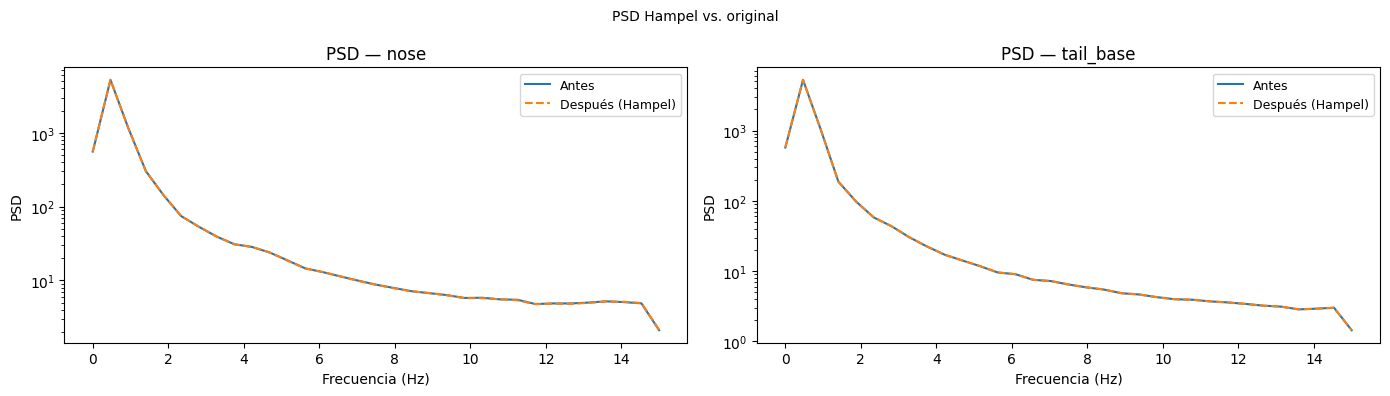

In [28]:
import time
import src.skeleton.keypoint_smoother as _ksm_h
import src.skeleton as _sk_h
from src.skeleton import hampel_correct_video
from src.skeleton.metrics import ks_velocity_test, psd_comparison_plot, temporal_fidelity_report

# ── Hampel parameters ────────────────────────────────────────────────────
HAMPEL_K  = 5     # half-window: 2*5+1 = 11 frames, about 0.37 s at 30 fps
HAMPEL_T0 = 3.0   # threshold in robust MAD units, the standard choice
CONF_THR  = 0.3   # confidence gating: frames with likelihood < 0.3 are ffilled

# ── Apply the Hampel correction to the raw data ──────────────────────────
_t0_h = time.perf_counter()
df_hampel, report_hampel = hampel_correct_video(
    tracking_df=df_sample,
    lab_id=LAB_ID,
    skeleton=skeleton,
    hampel_k=HAMPEL_K,
    hampel_t0=HAMPEL_T0,
    confidence_threshold=CONF_THR,
)
_perf_hampel = round(time.perf_counter() - _t0_h, 3)

print(f'Hampel completado en {_perf_hampel} s')
print(f'  Frames totales:      {report_hampel["n_total_frames"]}')
print(f'  Spikes corregidos:   {report_hampel["n_spikes_corrected"]}  '
      f'({report_hampel["spike_pct"]:.2f}% of keypoint-frames)')
print(f'  Confidence gated:    {report_hampel["n_conf_gated"]}')

# ── Test KS — Hampel vs. datos originales ─────────────────────────────────
print('\n── Test KS: Hampel vs. original ────────────────────────────────────')
for bp in _KEYPOINTS_FIDELITY:
    ks_s, ks_p = ks_velocity_test(
        df_sample, df_hampel,
        mouse_id=MOUSE_ID, fps=VIDEO_FPS, arena_diag=ARENA_DIAG, bodypart=bp,
    )
    interp = '✓ distribution unchanged' if ks_p > 0.05 else '⚠ distribution modified'
    print(f'  Hampel  {bp}: D={ks_s:.4f}  p={ks_p:.4f}  → {interp}')

print(f'\n── Test KS: {best_label} vs. original ──────────────────────────────')
for bp in _KEYPOINTS_FIDELITY:
    ks_s, ks_p = ks_velocity_test(
        df_sample, df_corrected,
        mouse_id=MOUSE_ID, fps=VIDEO_FPS, arena_diag=ARENA_DIAG, bodypart=bp,
    )
    interp = '✓ distribution unchanged' if ks_p > 0.05 else '⚠ distribution modified'
    print(f'  {best_label:12s} {bp}: D={ks_s:.4f}  p={ks_p:.4f}  → {interp}')

# ── Temporal fidelity report ─────────────────────────────────────────────
print('\n── Fidelidad temporal — Hampel ─────────────────────────────────────')
df_fid_h = temporal_fidelity_report(
    df_sample, df_hampel,
    mouse_id=MOUSE_ID, fps=VIDEO_FPS, arena_diag=ARENA_DIAG,
    label='Hampel', keypoints=_KEYPOINTS_FIDELITY,
)
print(df_fid_h.to_string(index=False, float_format='{:.6f}'.format))

# ── PSD comparativa ───────────────────────────────────────────────────────
print('\nPSD comparativa (Hampel vs. original):')
fig_h, axes_h = plt.subplots(1, len(_KEYPOINTS_FIDELITY),
                              figsize=(7 * len(_KEYPOINTS_FIDELITY), 4))
psd_comparison_plot(
    df_sample, df_hampel,
    mouse_id=MOUSE_ID, fps=VIDEO_FPS,
    keypoints=_KEYPOINTS_FIDELITY,
    after_label='Hampel',
    axes=axes_h if len(_KEYPOINTS_FIDELITY) > 1 else [axes_h],
)
plt.suptitle('PSD Hampel vs. original', fontsize=10)
plt.tight_layout()
plt.show()


## §7 Summary

Collects every metric from the experiment into a single dictionary, writes it to
JSON and Parquet, and builds the v1 to v3 comparison table with relative
reductions.

In [29]:
import json, os
from pathlib import Path

# ── Global effect size: Cohen's d over the per-edge rates ────────────────
_vr_b = viol_before['violation_rate'].values
_vr_a = viol_after['violation_rate'].values
_d_global = _cohens_d(_vr_b, _vr_a)
def _interp_d(d: float) -> str:
    d = abs(d)
    return 'negligible' if d < 0.2 else 'small' if d < 0.5 else 'medium' if d < 0.8 else 'large'

# ms per frame for the correction chosen as best
_best_time_key = {'v1': 'smooth_v1_s', 'v2': 'smooth_v2_s',
                  'v3': 'smooth_v3_s',  'v3b': 'smooth_v3b_s'}.get(best_label, 'smooth_v2_s')
_ms_per_frame = (_perf.get(_best_time_key, float('nan')) / FRAME_LIMIT * 1000)

summary = {
    # ── Experiment configuration ──────────────────────────────────────────
    'lab_id':             LAB_ID,
    'video_id':           VIDEO_ID,
    'n_frames':           FRAME_LIMIT,
    'mouse_id':           MOUSE_ID,
    'best_config':        best_label,
    # ── Violation rates ───────────────────────────────────────────────────
    'global_violation_rate_before': round(float(global_rate_before), 4),
    'global_violation_rate_after':  round(float(global_rate_after),  4),
    'reduction_pct': round((1 - global_rate_after / max(global_rate_before, 1e-9)) * 100, 2),
    # ── Effect size ───────────────────────────────────────────────────────
    'cohens_d_violations':         round(_d_global, 4),
    'effect_size_interpretation':  _interp_d(_d_global),
    # ── Rendimiento (profiling) ────────────────────────────────────────────
    'load_tracking_s':          _perf.get('load_tracking_s', None),
    'smooth_v1_s':              _perf.get('smooth_v1_s',     None),
    'smooth_v2_s':              _perf.get('smooth_v2_s',     None),
    'smooth_v3_s':              _perf.get('smooth_v3_s',     None),
    'smooth_v3b_s':             _perf.get('smooth_v3b_s',    None),
    'total_pipeline_s':         _perf.get('total_pipeline_s', None),
    'runtime_ms_per_frame_best': round(_ms_per_frame, 3) if not float('nan').__eq__(_ms_per_frame) else None,
    # ── Model parameters ──────────────────────────────────────────────────
    'length_threshold':   LENGTH_THRESHOLD,
    'speed_mad_k':        SPEED_MAD_K,
    'lambda_l':           LAMBDA_L,
    'lambda_t':           LAMBDA_T,
    'detection_n_sigma':  DETECTION_N_SIGMA,
    'arena_diag_px':      round(ARENA_DIAG, 2),
    'video_fps':          VIDEO_FPS,
}

print('=== Skeleton-correction summary ===')
for k, v in summary.items():
    print(f'  {k}: {v}')

# ── Exportar JSON ─────────────────────────────────────────────────────────
out_dir = Path('../outputs')
out_dir.mkdir(exist_ok=True)

out_json = out_dir / 'skeleton_correction_summary.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'\n✓ JSON exportado → {out_json}')

# ── Export Parquet, for downstream analysis with pd.read_parquet ─────────
out_parquet = out_dir / 'skeleton_correction_summary.parquet'
pd.DataFrame([summary]).to_parquet(out_parquet, index=False)
print(f'✓ Parquet exportado → {out_parquet}')


=== Resumen de corrección de esqueleto ===
  lab_id: CalMS21_task1
  video_id: 13638642
  n_frames: 1500
  mouse_id: 1
  best_config: v3 (α=0.30)
  global_violation_rate_before: 0.111
  global_violation_rate_after: 0.0277
  reduction_pct: 75.02
  cohens_d_violations: 1.3105
  effect_size_interpretation: large
  load_tracking_s: 0.787
  smooth_v1_s: 27.34
  smooth_v2_s: 30.94
  smooth_v3_s: 15.303
  smooth_v3b_s: 14.154
  total_pipeline_s: 87.737
  runtime_ms_per_frame_best: 20.627
  length_threshold: 1.84
  speed_mad_k: 3.5
  lambda_l: 12.0
  lambda_t: 0.8
  detection_n_sigma: 5.0
  arena_diag_px: 1171.95
  video_fps: 30.0

✓ JSON exportado → ..\outputs\skeleton_correction_summary.json
✓ Parquet exportado → ..\outputs\skeleton_correction_summary.parquet


In [30]:
# ── Variant comparison table ─────────────────────────────────────────────────────────────
_versions = ['before', 'v1 (uniform λ)', 'v2 (auto λ)', 'v3 (multi-pass)']
_viol_rates = [
    float(global_rate_before),
    float(viol_v1['vr_v1'].mean()),
    float(viol_v2['vr_v2'].mean()),
    float(global_rate_after),
]
_displacements = [
    0.0,
    float(report_v1.get('mean_displacement_px', float('nan'))),
    float(report_v2.get('mean_displacement_px', float('nan'))),
    float(report_v3.get('mean_displacement_px', float('nan'))),
]
_runtimes = [
    0.0,
    _perf.get('smooth_v1_s', float('nan')),
    _perf.get('smooth_v2_s', float('nan')),
    _perf.get('smooth_v3_s', float('nan')),
]

df_exp_summary = pd.DataFrame({
    'version':              _versions,
    'global_viol_rate':     _viol_rates,
    'mean_displacement_px': _displacements,
    'runtime_s':            _runtimes,
})
df_exp_summary['viol_reduction_%'] = (
    (df_exp_summary['global_viol_rate'].iloc[0] - df_exp_summary['global_viol_rate'])
    / max(df_exp_summary['global_viol_rate'].iloc[0], 1e-9) * 100
).round(1)

display(
    df_exp_summary.style
    .highlight_min(subset=['global_viol_rate'], color='#c6efce')
    .highlight_max(subset=['viol_reduction_%'], color='#c6efce')
    .format({
        'global_viol_rate':     '{:.2%}',
        'mean_displacement_px': '{:.1f}',
        'runtime_s':            '{:.2f}',
        'viol_reduction_%':     '{:+.1f}%',
    })
    .set_caption(f'Variant summary  ·  {LAB_ID}  ·  {VIDEO_ID}')
)


,version,global_viol_rate,mean_displacement_px,runtime_s,viol_reduction_%
0,antes,11.10%,0.0,0.00,+0.0%
1,v1 (λ uniforme),8.80%,8.5,27.34,+20.7%
2,v2 (λ auto),4.23%,3.9,30.94,+61.9%
3,v3 (multi-paso),2.77%,4.4,15.30,+75.0%


In [31]:
# ── Persist the results under results/ ──────────────────────────────────────────────────
from pathlib import Path

RESULTS_DIR = Path(REPO_ROOT) / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

_tag = f'{LAB_ID}_{VIDEO_ID}'
_best_ver = best_label.split()[0]   # e.g. 'v3b' or 'v3'

# 1. DataFrame corregido (mejor variante)
_pkl_path = RESULTS_DIR / f'smooth_{_best_ver}_{_tag}.pkl'
df_corrected.to_pickle(_pkl_path)
print(f'✓ df_corrected    → {_pkl_path}')

# 2. Violations before and after, in long format
_viol_b_exp = viol_before[['edge', 'violation_rate']].copy()
_viol_b_exp['phase'] = 'before'
_viol_a_exp = viol_after[['edge', 'violation_rate']].copy()
_viol_a_exp['phase'] = 'after'
_viol_csv = RESULTS_DIR / f'violations_before_after_{_tag}.csv'
pd.concat([_viol_b_exp, _viol_a_exp]).to_csv(_viol_csv, index=False)
print(f'✓ violations     → {_viol_csv}')

# 3. Experiment summary table
_summary_csv = RESULTS_DIR / f'experiment_summary_{_tag}.csv'
df_exp_summary.to_csv(_summary_csv, index=False)
print(f'✓ exp_summary    → {_summary_csv}')


✓ df_corrected    → c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\results\smooth_v3_CalMS21_task1_13638642.pkl
✓ violations     → c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\results\violations_before_after_CalMS21_task1_13638642.csv
✓ exp_summary    → c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\results\experiment_summary_CalMS21_task1_13638642.csv


In [32]:
# ── §10 — Persistent artifact export (for downstream notebooks) ──────────────
import pickle, json
from pathlib import Path

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# ── Run-level config (video_id / mouse_id resolved in §2) ────────────────────
_run_cfg = {
    "video_id":  VIDEO_ID,
    "lab_id":    LAB_ID,
    "mouse_id":  MOUSE_ID,
    "arena_diag": ARENA_DIAG,
    "video_fps": VIDEO_FPS,
}
with open(RESULTS_DIR / "run_config.json", "w", encoding="utf-8") as _f:
    json.dump(_run_cfg, _f, indent=2)

# ── DataFrames ────────────────────────────────────────────────────────────────
with open(RESULTS_DIR / f"df_sample_{VIDEO_ID}.pkl",    "wb") as _f:
    pickle.dump(df_sample, _f)
with open(RESULTS_DIR / f"df_corrected_{VIDEO_ID}.pkl", "wb") as _f:
    pickle.dump(df_corrected, _f)

# ── Skeleton ──────────────────────────────────────────────────────────────────
with open(RESULTS_DIR / f"skeleton_{LAB_ID}.pkl", "wb") as _f:
    pickle.dump(skeleton, _f)

print(f"✓  run_config.json")
print(f"✓  df_sample_{VIDEO_ID}.pkl  ({len(df_sample)} rows)")
print(f"✓  df_corrected_{VIDEO_ID}.pkl  ({len(df_corrected)} rows)")
print(f"✓  skeleton_{LAB_ID}.pkl")
print(f"All artifacts → {RESULTS_DIR}/")


✓  run_config.json
✓  df_sample_13638642.pkl  (21000 rows)
✓  df_corrected_13638642.pkl  (21000 rows)
✓  skeleton_CalMS21_task1.pkl
All artifacts → c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\results/


## §11 On-disk correction cache, in parallel

`build_correction_cache` corrects each video once and stores it at
`dataset/corrected/<lab>/<video>__<hash>.parquet`. Later runs reload from Parquet in
about 0.03 s.

This is what makes it affordable to run the pipeline over many videos: without it,
every multi-video experiment pays the full correction cost again.

In [33]:
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

from src.data.correction_cache import build_correction_cache
from src.data.loader import TRAIN_TRACKING_DIR
import pandas as pd

vids = [f.stem for f in sorted((TRAIN_TRACKING_DIR / "CalMS21_task1").glob("*.parquet"))[:5]]
skw = dict(auto_edge_lambdas=True, lambda_l=12.0, lambda_t=0.8, detection_n_sigma=3.0)
rows = build_correction_cache(vids, "CalMS21_task1", skw, frame_limit=400, workers=2)
# Re-run is all cache hits (~0.03 s/video): correction is paid once, then reused.
pd.DataFrame(rows)


,video_id,n_frames,elapsed_s,from_cache,hash,error
0,1036913557,400,0.03,True,fc3baef360,None
1,1011533560,400,0.03,True,fc3baef360,None
2,1062887364,400,0.02,True,fc3baef360,None
3,1087101060,400,0.02,True,fc3baef360,None
4,1089428234,400,0.03,True,fc3baef360,None
